In [1]:
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("Number of GPUs:", torch.cuda.device_count())
    print("Current GPU index:", torch.cuda.current_device())
    print("GPU Name:", torch.cuda.get_device_name(torch.cuda.current_device()))

PyTorch version: 2.7.0+cu128
CUDA available: True
Number of GPUs: 1
Current GPU index: 0
GPU Name: NVIDIA GeForce RTX 5080 Laptop GPU


In [2]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# Optional: interactive plots
try:
    import plotly.express as px
    import plotly.graph_objects as go
    PLOTLY_AVAILABLE = True
except ImportError:
    PLOTLY_AVAILABLE = False
    print("Plotly not installed. Skipping interactive plots. Install with: pip install plotly")

# Plot styling
sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 12

# ── CONFIG ──────────────────────────────────────────────────────────────────
H5_PATH = r"C:\Users\sarat\Downloads\GP\GP-AI-Electricity-Advisor\data nilm\ukdale.h5"  # <-- change if your file is elsewhere
HOUSE        = 1             # which house to analyse (1-5 in UK-DALE)
RESAMPLE_FREQ = '1min'       # resampling frequency
# ─────────────────────────────────────────────────────────────────────────────

print('All libraries imported successfully.')
print(f'Plotly available: {PLOTLY_AVAILABLE}')

All libraries imported successfully.
Plotly available: True


In [3]:
# ── Helper: list all meters available for the chosen house ──────────────────
def list_meters(h5_path, house):
    """Return a list of meter keys for a given house."""
    with pd.HDFStore(h5_path, mode='r') as store:
        all_keys = store.keys()
    prefix = f'/building{house}/elec/'
    meters = sorted([k for k in all_keys if k.startswith(prefix)])
    return meters

meters = list_meters(H5_PATH, HOUSE)
print(f'House {HOUSE} — meters found ({len(meters)}):')
for m in meters:
    print(' ', m)

House 1 — meters found (54):
  /building1/elec/meter1
  /building1/elec/meter10
  /building1/elec/meter11
  /building1/elec/meter12
  /building1/elec/meter13
  /building1/elec/meter14
  /building1/elec/meter15
  /building1/elec/meter16
  /building1/elec/meter17
  /building1/elec/meter18
  /building1/elec/meter19
  /building1/elec/meter2
  /building1/elec/meter20
  /building1/elec/meter21
  /building1/elec/meter22
  /building1/elec/meter23
  /building1/elec/meter24
  /building1/elec/meter25
  /building1/elec/meter26
  /building1/elec/meter27
  /building1/elec/meter28
  /building1/elec/meter29
  /building1/elec/meter3
  /building1/elec/meter30
  /building1/elec/meter31
  /building1/elec/meter32
  /building1/elec/meter33
  /building1/elec/meter34
  /building1/elec/meter35
  /building1/elec/meter36
  /building1/elec/meter37
  /building1/elec/meter38
  /building1/elec/meter39
  /building1/elec/meter4
  /building1/elec/meter40
  /building1/elec/meter41
  /building1/elec/meter42
  /building1/

In [4]:
import tables
import numpy as np

def load_meter(h5_path, house, meter_id):
    """
    Load meter using PyTables directly.
    """
    with tables.open_file(h5_path, mode='r') as f:
        node = f.get_node(f'/building{house}/elec/meter{meter_id}/table')
        data = node.read()
    
    timestamps = data['index']      # int64 nanoseconds
    power      = data['values_block_0'].flatten()  # float32
    
    index = pd.to_datetime(timestamps, unit='ns', utc=True)
    index = index.tz_convert('Europe/London')
    
    series = pd.Series(power, index=index, name=f'meter{meter_id}')
    return series


# ── Reload all meters ────────────────────────────────────────────────────────
METER_IDS = [int(m.split('meter')[-1]) for m in meters[:min(6, len(meters))]]

raw = {}
for mid in METER_IDS:
    try:
        raw[mid] = load_meter(H5_PATH, HOUSE, mid)
        print(f'  meter{mid}: {len(raw[mid]):,} readings  '
              f'[{raw[mid].index.min()} → {raw[mid].index.max()}]')
    except Exception as e:
        print(f'  meter{mid}: FAILED — {e}')

  meter1: 10,239,433 readings  [2012-11-09 22:28:15+00:00 → 2015-01-05 06:15:46+00:00]
  meter10: 8,942,091 readings  [2012-11-09 22:28:18+00:00 → 2015-01-05 06:16:04+00:00]
  meter11: 8,989,484 readings  [2012-12-14 22:21:32+00:00 → 2015-01-05 06:16:28+00:00]
  meter12: 8,972,363 readings  [2012-12-14 22:21:32+00:00 → 2015-01-05 06:16:43+00:00]
  meter13: 9,018,806 readings  [2012-12-14 22:21:33+00:00 → 2015-01-05 06:17:02+00:00]
  meter14: 2,150,625 readings  [2012-12-14 22:21:33+00:00 → 2014-12-24 20:55:59+00:00]


In [5]:
# ── Quick overview of the mains series ──────────────────────────────────────
mains = raw[1]
print('=== Mains overview ===')
print(f'  Shape       : {mains.shape}')
print(f'  dtype       : {mains.dtype}')
print(f'  Index type  : {type(mains.index)}')
print(f'  Time range  : {mains.index.min()}  →  {mains.index.max()}')
print(f'  Missing (%) : {mains.isna().mean()*100:.2f}%')
print()
print(mains.describe())

=== Mains overview ===
  Shape       : (10239433,)
  dtype       : float32
  Index type  : <class 'pandas.DatetimeIndex'>
  Time range  : 2012-11-09 22:28:15+00:00  →  2015-01-05 06:15:46+00:00
  Missing (%) : 0.00%

count    1.023943e+07
mean     3.567997e+02
std      4.179086e+02
min      4.600000e+01
25%      1.840000e+02
50%      2.390000e+02
75%      3.700000e+02
max      8.423000e+03
Name: meter1, dtype: float64


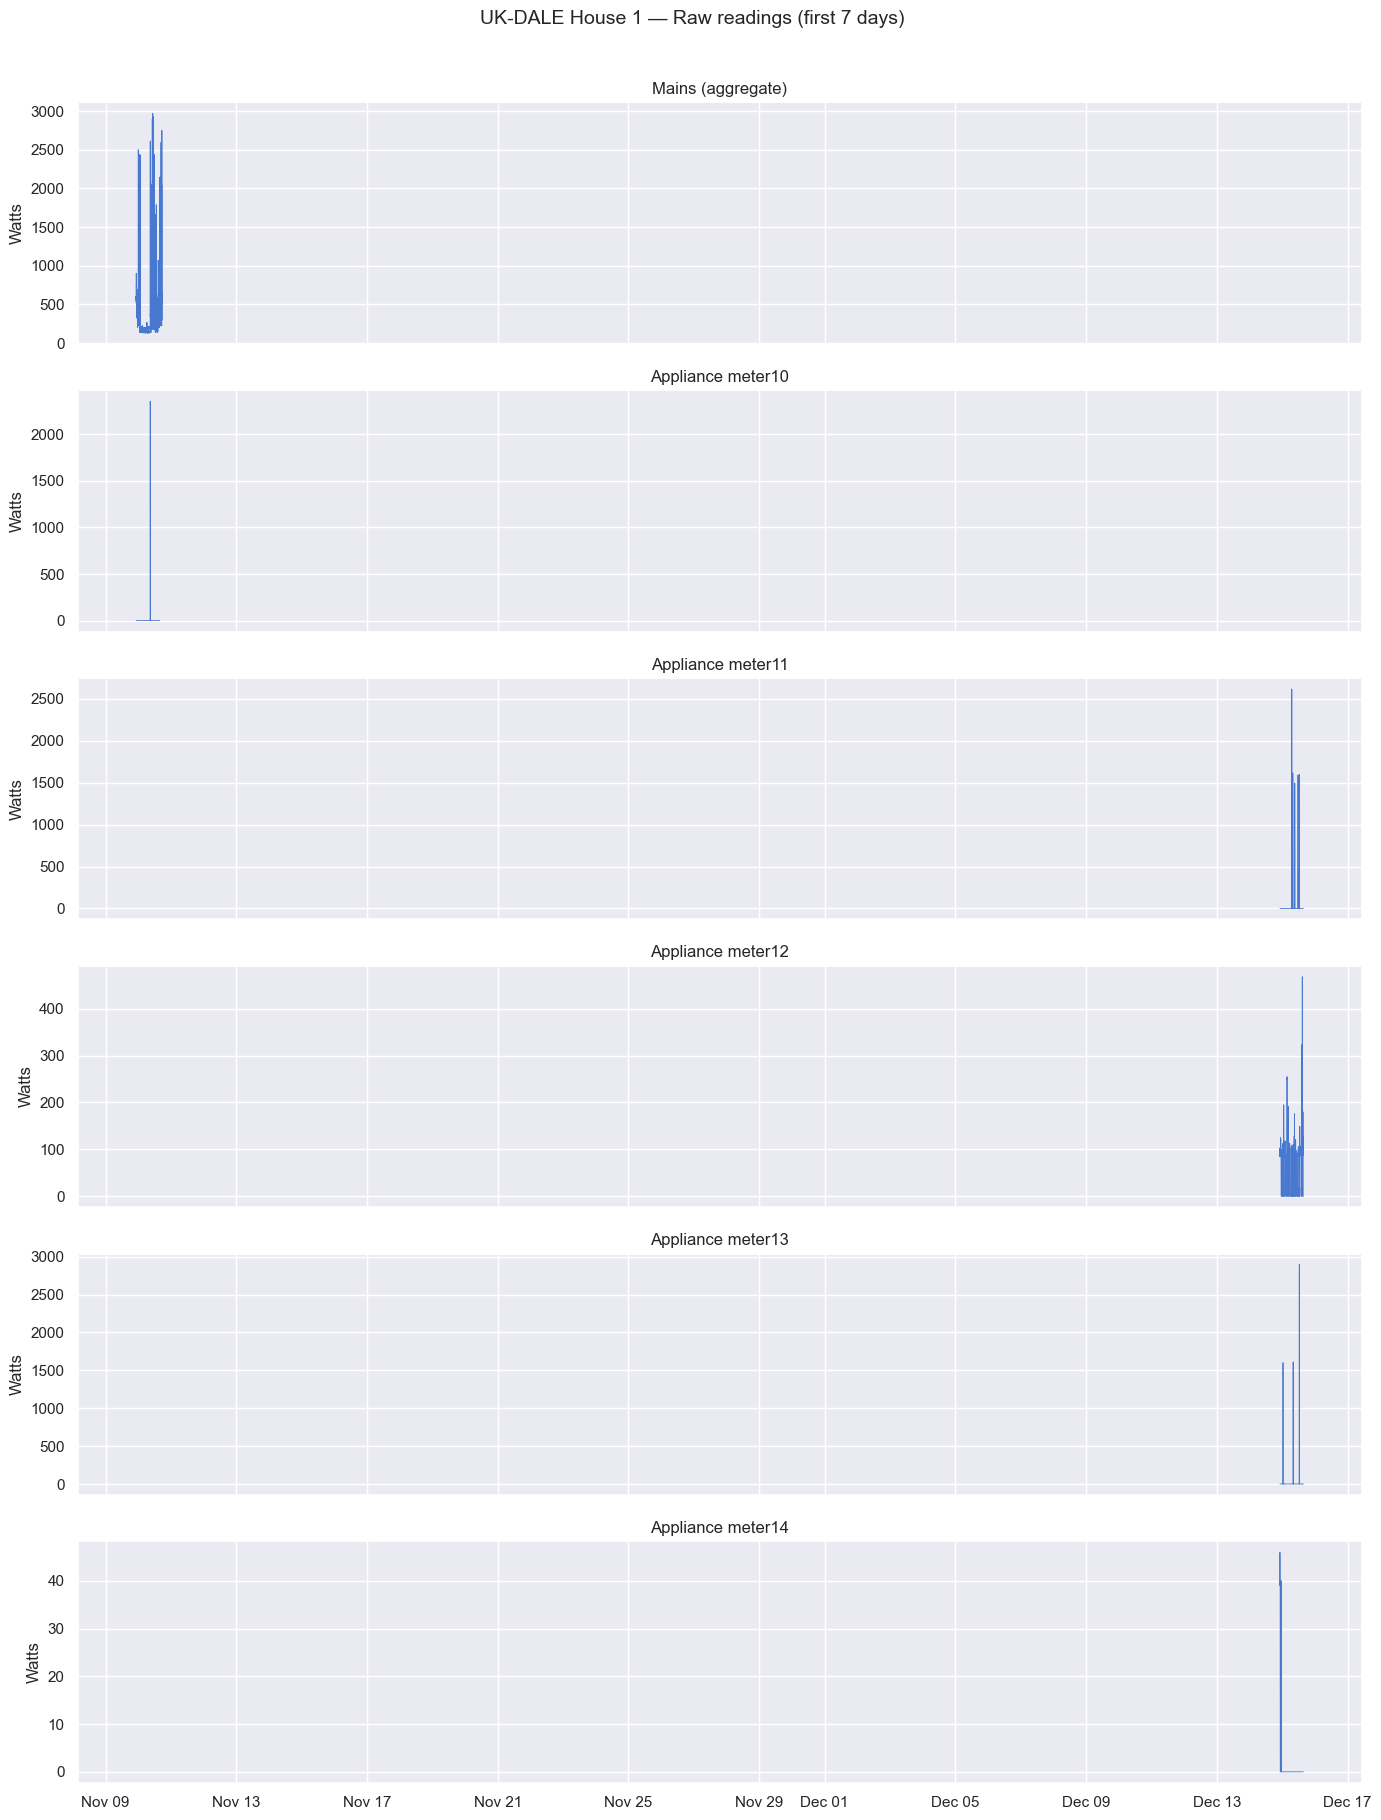

In [6]:
# ── Initial time-series plot: mains + appliances ────────────────────────────
fig, axes = plt.subplots(len(raw), 1, figsize=(14, 3 * len(raw)), sharex=True)
if len(raw) == 1:
    axes = [axes]

labels = {1: 'Mains (aggregate)'}

for ax, (mid, series) in zip(axes, raw.items()):
    # Plot a random 7-day window for readability
    sample = series.iloc[:60*24*7]  # first 7 days
    ax.plot(sample.index, sample.values, linewidth=0.6)
    ax.set_ylabel('Watts')
    ax.set_title(labels.get(mid, f'Appliance meter{mid}'))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))

plt.suptitle(f'UK-DALE House {HOUSE} — Raw readings (first 7 days)', y=1.01, fontsize=14)
plt.tight_layout()
plt.show()

In [7]:
# Analyse the time gaps between consecutive readings in the mains meter.
# This is important because the dataset has NO NaN values — meaning missing
# data doesn't show up as NaN, it shows up as MISSING TIMESTAMPS (the sensor
# simply stopped recording). We need to find these hidden gaps.

gaps = pd.Series(mains.index).diff().dt.total_seconds().dropna()

# ── Basic gap stats ──────────────────────────────────────────────────────────
print('=== Gap Statistics (seconds between consecutive readings) ===')
print(f'  Total readings     : {len(mains):,}')
print(f'  Median gap         : {gaps.median():.0f} sec  ← this is your normal sampling rate')
print(f'  Mean gap           : {gaps.mean():.1f} sec')
print(f'  Max gap            : {gaps.max():.0f} sec  ({gaps.max()/3600:.1f} hours)  ← longest outage')
print(f'  Min gap            : {gaps.min():.0f} sec')

# ── How often does each gap size appear? ────────────────────────────────────
print('\n=== Most common gap sizes (top 10) ===')
print('  (This tells you the normal rhythm of the sensor)')
vc = gaps.value_counts().head(10)
for gap_val, count in vc.items():
    pct = count / len(gaps) * 100
    print(f'  {gap_val:6.0f} sec  →  {count:>10,} readings  ({pct:.2f}% of the time)')

# ── How many gaps exceed each threshold? ────────────────────────────────────
print('\n=== Number of gaps exceeding thresholds ===')
print('  (These are the "blackout" periods where data is missing)')
thresholds = [
    (60,    '1 minute  '),
    (300,   '5 minutes '),
    (3600,  '1 hour    '),
    (86400, '1 day     '),
]
for t, label in thresholds:
    n = (gaps > t).sum()
    total_missing_hrs = gaps[gaps > t].sum() / 3600
    print(f'  Gaps > {label}: {n:>6,} occurrences  '
          f'(~{total_missing_hrs:.1f} total hours of missing data)')

# ── Where are the biggest gaps? ─────────────────────────────────────────────
print('\n=== Top 10 longest gaps (where did the sensor go offline?) ===')
print('  (Any gap > ~10 min should NOT be interpolated — it would be fake data)')
top_gaps = gaps.nlargest(10)
for rank, (idx, val) in enumerate(top_gaps.items(), 1):
    ts = mains.index[idx]
    print(f'  {rank:2}. {val/3600:7.1f} hours  starting at  {ts}')

# ── Summary conclusion ───────────────────────────────────────────────────────
print('\n=== Conclusion ===')
print(f'  Normal sampling rate : every {gaps.median():.0f} seconds')
print(f'  After resampling to 1-min, gaps > 10 min will become NaN rows')
print(f'  → Only interpolate gaps under 10 minutes (fill limit = 10 rows at 1-min freq)')
print(f'  → Flag longer gaps so the ML model ignores those windows')


=== Gap Statistics (seconds between consecutive readings) ===
  Total readings     : 10,239,433
  Median gap         : 6 sec  ← this is your normal sampling rate
  Mean gap           : 6.6 sec
  Max gap            : 985799 sec  (273.8 hours)  ← longest outage
  Min gap            : 5 sec

=== Most common gap sizes (top 10) ===
  (This tells you the normal rhythm of the sensor)
       6 sec  →   8,590,359 readings  (83.89% of the time)
       7 sec  →   1,401,894 readings  (13.69% of the time)
       5 sec  →      88,987 readings  (0.87% of the time)
      12 sec  →      74,774 readings  (0.73% of the time)
      13 sec  →      42,718 readings  (0.42% of the time)
      18 sec  →      12,935 readings  (0.13% of the time)
      19 sec  →      10,424 readings  (0.10% of the time)
      20 sec  →       3,150 readings  (0.03% of the time)
      25 sec  →       2,715 readings  (0.03% of the time)
      24 sec  →       2,645 readings  (0.03% of the time)

=== Number of gaps exceeding threshol

In [8]:
gaps = pd.Series(mains.index).diff().dt.total_seconds().dropna()

# ── How many gaps exceed each threshold? ────────────────────────────────────
# These are periods where the sensor went offline / stopped recording
# After resampling to 1-min, these will become NaN rows in your DataFrame
print('=== Gap Analysis ===')
print('(How many times did the sensor go silent for longer than each threshold?)\n')

thresholds = [60, 300, 3600, 86400]  # 1min, 5min, 1hr, 1day
for t in thresholds:
    n = (gaps > t).sum()
    total_hrs = gaps[gaps > t].sum() / 3600
    label = f'{t//60}min' if t >= 60 else f'{t}sec'
    print(f'  Gaps > {label:8s}: {n:>6,} occurrences  '
          f'(~{total_hrs:.1f} total hours of lost data)')

# ── Where exactly did the biggest dropouts happen? ──────────────────────────
# These timestamps mark where your data has holes too large to interpolate.
# Any gap > 10 min should be left as NaN — interpolating across hours/days
# would just be making up data, which would mislead your ML model.
print(f'\n=== Top 10 Longest Gaps ===')
print('(Periods where interpolation is NOT safe — leave these as NaN)\n')
top_gaps = gaps.nlargest(10)
for i, (idx, val) in enumerate(top_gaps.items()):
    ts = mains.index[idx]
    end_ts = mains.index[min(idx, len(mains.index)-1)]
    print(f'  {i+1:2}. {val/3600:7.1f} hours  starting at  {ts}')

print('\n=== Conclusion ===')
print('  → Safe to interpolate : gaps under 10 minutes only')
print('  → Leave as NaN        : gaps over 10 minutes (sensor was truly offline)')
print('  → After resampling to 1-min, check NaN % — if high, consider trimming date range')

=== Gap Analysis ===
(How many times did the sensor go silent for longer than each threshold?)

  Gaps > 1min    :    445 occurrences  (~1068.8 total hours of lost data)
  Gaps > 5min    :     82 occurrences  (~1058.7 total hours of lost data)
  Gaps > 60min   :     28 occurrences  (~1040.0 total hours of lost data)
  Gaps > 1440min :      8 occurrences  (~938.2 total hours of lost data)

=== Top 10 Longest Gaps ===
(Periods where interpolation is NOT safe — leave these as NaN)

   1.   273.8 hours  starting at  2013-02-08 18:06:29+00:00
   2.   218.7 hours  starting at  2012-12-12 12:48:33+00:00
   3.   174.1 hours  starting at  2013-01-17 17:38:32+00:00
   4.   118.6 hours  starting at  2012-12-22 16:46:27+00:00
   5.    65.5 hours  starting at  2012-11-26 13:03:34+00:00
   6.    34.5 hours  starting at  2012-11-19 19:56:43+00:00
   7.    26.7 hours  starting at  2013-03-11 10:17:40+00:00
   8.    26.3 hours  starting at  2013-02-11 08:59:05+00:00
   9.    21.7 hours  starting at  20

In [9]:
def preprocess_meter(series, freq='1min', max_gap_minutes=10):
    """
    Clean and resample a raw meter Series.
    
    Steps:
    1. Remove duplicate timestamps
    2. Sort by time
    3. Clip negative values to 0
    4. Resample to uniform 1-min intervals
    5. Interpolate small gaps (under max_gap_minutes)
    6. Leave large gaps as NaN (don't fake data)
    """
    s = series.copy()
    
    # ── Step 1: Remove duplicate timestamps ─────────────────────────────────
    n_dupes = s.index.duplicated().sum()
    s = s[~s.index.duplicated(keep='first')]
    print(f'  [{series.name}] Duplicates removed: {n_dupes}')
    
    # ── Step 2: Sort by time ─────────────────────────────────────────────────
    s = s.sort_index()
    
    # ── Step 3: Clip negatives ───────────────────────────────────────────────
    # Negative watts are physically impossible — sensor glitches
    n_neg = (s < 0).sum()
    s = s.clip(lower=0)
    print(f'  [{series.name}] Negative values clipped: {n_neg}')
    
    # ── Step 4: Resample to 1-min intervals ──────────────────────────────────
    # Takes the mean of all readings within each 1-minute window
    # Minutes with no readings become NaN (these are our gap periods)
    s_resampled = s.resample(freq).mean()
    n_nan_after_resample = s_resampled.isna().sum()
    print(f'  [{series.name}] NaN after resampling: {n_nan_after_resample:,} '
          f'({n_nan_after_resample/len(s_resampled)*100:.2f}% of minutes)')
    
    # ── Step 5: Interpolate small gaps only ──────────────────────────────────
    # limit=max_gap_minutes means we only fill up to 10 consecutive NaN rows
    # Larger gaps stay as NaN — we won't make up data for long outages
    s_resampled = s_resampled.interpolate(method='time', limit=max_gap_minutes)
    n_nan_after_interp = s_resampled.isna().sum()
    n_filled = n_nan_after_resample - n_nan_after_interp
    print(f'  [{series.name}] Small gaps filled by interpolation: {n_filled:,}')
    print(f'  [{series.name}] Large gaps left as NaN: {n_nan_after_interp:,} '
          f'({n_nan_after_interp/len(s_resampled)*100:.2f}% of minutes)')
    print()
    
    return s_resampled


# ── Preprocess all loaded meters ─────────────────────────────────────────────
print('=== Preprocessing all meters ===\n')
clean = {}
for mid, series in raw.items():
    clean[mid] = preprocess_meter(series)

# ── Combine into one DataFrame ───────────────────────────────────────────────
df = pd.DataFrame(clean)
df.columns = [f'meter{c}' for c in df.columns]
df.rename(columns={'meter1': 'mains'}, inplace=True)
df.index.name = 'timestamp'

print('=== Combined DataFrame ===')
print(f'  Shape        : {df.shape}')
print(f'  Time range   : {df.index.min()}  →  {df.index.max()}')
print(f'  Total NaN    : {df.isna().sum().sum():,}')
print(f'\nNaN per column:')
for col in df.columns:
    pct = df[col].isna().mean() * 100
    print(f'  {col:12s}: {df[col].isna().sum():>8,} NaN  ({pct:.2f}%)')

=== Preprocessing all meters ===

  [meter1] Duplicates removed: 0
  [meter1] Negative values clipped: 0
  [meter1] NaN after resampling: 63,694 (5.63% of minutes)
  [meter1] Small gaps filled by interpolation: 977
  [meter1] Large gaps left as NaN: 62,717 (5.54% of minutes)

  [meter10] Duplicates removed: 0
  [meter10] Negative values clipped: 0
  [meter10] NaN after resampling: 88,481 (7.81% of minutes)
  [meter10] Small gaps filled by interpolation: 5,703
  [meter10] Large gaps left as NaN: 82,778 (7.31% of minutes)

  [meter11] Duplicates removed: 0
  [meter11] Negative values clipped: 0
  [meter11] NaN after resampling: 39,749 (3.67% of minutes)
  [meter11] Small gaps filled by interpolation: 932
  [meter11] Large gaps left as NaN: 38,817 (3.59% of minutes)

  [meter12] Duplicates removed: 0
  [meter12] Negative values clipped: 0
  [meter12] NaN after resampling: 36,218 (3.35% of minutes)
  [meter12] Small gaps filled by interpolation: 2,013
  [meter12] Large gaps left as NaN: 34

Meter 14 — problem

78.91% NaN is way too high
this appliance was either unplugged, broken, or only monitored for a short period
we should drop meter14, it has almost no useful data

In [10]:
# Drop meter14 — 79% NaN makes it unusable for ML
df.drop(columns=['meter14'], inplace=True)

print('=== Final DataFrame after dropping meter14 ===')
print(f'  Shape      : {df.shape}')
print(f'  Columns    : {list(df.columns)}')
print(f'  Time range : {df.index.min()}  →  {df.index.max()}')
print(f'\nNaN summary:')
for col in df.columns:
    pct = df[col].isna().mean() * 100
    print(f'  {col:12s}: {pct:.2f}% NaN')

=== Final DataFrame after dropping meter14 ===
  Shape      : (1132310, 5)
  Columns    : ['mains', 'meter10', 'meter11', 'meter12', 'meter13']
  Time range : 2012-11-09 22:28:00+00:00  →  2015-01-05 06:17:00+00:00

NaN summary:
  mains       : 5.54% NaN
  meter10     : 7.31% NaN
  meter11     : 7.88% NaN
  meter12     : 7.47% NaN
  meter13     : 7.47% NaN


we have 5 houses and they all have the same appliances, which is gonna make it hard to train one model for all houses AND all appliances 
in this dataset we have 5 appliances [kettle, microwave, washing machine, fridge, dishwasher]
so we're gonna train 5 model , one model for each applince across all houses 
this method is *called cross-building generalization* 

*House 1 (from building1.yaml):*

meter1 = mains, meter10 = kettle, meter11 = toaster, meter12 = fridge_freezer, meter13 = microwave

*House 2 (from building2.yaml):*

meter20 = mains, meter8 = kettle, meter12 = washing_machine, meter13 = dishwasher, meter14 = fridge, meter15 = microwave

*House 3 (from building3.yaml):*

meter1 = mains, meter2 = kettle

*House 4 (from building4.yaml):*

meter1 = mains, meter3 = kettle, meter6 = washing_machine+microwave

*House 5 (from building5.yaml):*

meter26 = mains, meter18 = kettle, meter19 = fridge_freezer, meter22 = dishwasher, meter23 = microwave, meter24 = washing_machine

before we only loaded house one , now were gonna load them all

In [11]:
import tables
import numpy as np
import pandas as pd

# ── Appliance map: {house: {appliance_name: meter_id}} ──────────────────────
# Based on building1-5.yaml metadata files
# meter_id 'mains' points to the site meter for each house

HOUSE_APPLIANCE_MAP = {
    1: {
        'mains'           : 1,
        'kettle'          : 10,
        'toaster'         : 11,
        'fridge_freezer'  : 12,
        'microwave'       : 13,
        'washing_machine' : 5,
        'dishwasher'      : 6,
    },
    2: {
        'mains'           : 20,
        'kettle'          : 8,
        'fridge_freezer'  : 14,
        'microwave'       : 15,
        'washing_machine' : 12,
        'dishwasher'      : 13,
    },
    3: {
        'mains'           : 1,
        'kettle'          : 2,
    },
    4: {
        'mains'           : 1,
        'kettle'          : 3,
        'washing_machine' : 6,
    },
    5: {
        'mains'           : 26,
        'kettle'          : 18,
        'fridge_freezer'  : 19,
        'microwave'       : 23,
        'washing_machine' : 24,
        'dishwasher'      : 22,
    },
}


In [ ]:
# ── Appliances we care about for NILM ───────────────────────────────────────
TARGET_APPLIANCES = ['kettle', 'microwave', 'fridge_freezer', 
                     'washing_machine', 'dishwasher', 'toaster']


def load_meter(h5_path, house, meter_id):
    """
    Load one meter using PyTables directly.
    - Single column meters (shape N,1): appliance meters → use col 0
    - Three column meters (shape N,3): mains SoundCard → use col 1 (active power)
    """
    with tables.open_file(h5_path, mode='r') as f:
        node = f.get_node(f'/building{house}/elec/meter{meter_id}/table')
        data = node.read()

    timestamps = data['index']
    power_data = data['values_block_0']

    if power_data.ndim == 2:
        n_cols = power_data.shape[1]
        if n_cols == 3:
            # SoundCardPowerMeter: [apparent_power, active_power, voltage]
            # We want active power = column 1
            power = power_data[:, 1]
        else:
            # Single value stored as 2D array (N, 1) → just flatten
            power = power_data[:, 0]
    else:
        power = power_data.flatten()

    index = pd.to_datetime(timestamps, unit='ns', utc=True)
    index = index.tz_convert('Europe/London')

    return pd.Series(power, index=index, name=f'meter{meter_id}')


def preprocess_meter(series, freq='1min', max_gap_minutes=10):
    """Clean and resample a raw meter Series."""
    s = series.copy()
    if not isinstance(s.index, pd.DatetimeIndex):
        s.index = pd.to_datetime(s.index, utc=True)
    s = s[~s.index.duplicated(keep='first')]
    s = s.sort_index()
    s = s.clip(lower=0)
    s_resampled = s.resample(freq).mean()
    s_resampled = s_resampled.interpolate(method='time', limit=max_gap_minutes)
    return s_resampled


def load_house(h5_path, house, appliance_map):
    """
    Load mains + all available appliances for one house.
    Returns a DataFrame with columns: mains, kettle, microwave, etc.
    Plus a 'house' column for identification.
    """
    print(f'\n=== Loading House {house} ===')
    house_data = {}

    for appliance, meter_id in appliance_map.items():
        try:
            raw = load_meter(h5_path, house, meter_id)
            clean = preprocess_meter(raw)
            house_data[appliance] = clean
            print(f'  ✅ {appliance:20s} (meter{meter_id}): '
                  f'{len(clean):,} rows | '
                  f'NaN: {clean.isna().mean()*100:.1f}%')
        except Exception as e:
            print(f'  {appliance:20s} (meter{meter_id}): FAILED — {e}')

    if not house_data:
        print(f'  No data loaded for house {house}!')
        return None

    # Combine into DataFrame
    df = pd.DataFrame(house_data)
    df['house'] = house  # tag which house this row belongs to
    df.index.name = 'timestamp'
    return df


In [13]:
# ── Load all houses ──────────────────────────────────────────────────────────
all_houses = {}
for house, appliance_map in HOUSE_APPLIANCE_MAP.items():
    df_house = load_house(H5_PATH, house, appliance_map)
    if df_house is not None:
        all_houses[house] = df_house

print('\n\n=== Summary ===')
for house, df in all_houses.items():
    print(f'\nHouse {house}:')
    print(f'  Shape     : {df.shape}')
    print(f'  Time range: {df.index.min()} → {df.index.max()}')
    print(f'  Columns   : {[c for c in df.columns if c != "house"]}')


=== Loading House 1 ===
  ✅ mains                (meter1): 1,132,308 rows | NaN: 5.5%
  ✅ kettle               (meter10): 1,132,309 rows | NaN: 7.3%
  ✅ toaster              (meter11): 1,081,916 rows | NaN: 3.6%
  ✅ fridge_freezer       (meter12): 1,081,916 rows | NaN: 3.2%
  ✅ microwave            (meter13): 1,081,917 rows | NaN: 3.2%
  ✅ washing_machine      (meter5): 1,132,318 rows | NaN: 6.0%
  ✅ dishwasher           (meter6): 1,132,318 rows | NaN: 4.9%

=== Loading House 2 ===
  ✅ mains                (meter20): 253,952 rows | NaN: 20.2%
  ✅ kettle               (meter8): 337,756 rows | NaN: 36.4%
  ✅ fridge_freezer       (meter14): 204,948 rows | NaN: 15.7%
  ✅ microwave            (meter15): 204,948 rows | NaN: 15.7%
  ✅ washing_machine      (meter12): 204,948 rows | NaN: 15.7%
  ✅ dishwasher           (meter13): 204,948 rows | NaN: 15.7%

=== Loading House 3 ===
  ✅ mains                (meter1): 56,680 rows | NaN: 6.7%
  ✅ kettle               (meter2): 56,681 rows | NaN: 7.0

In [14]:
# ── Combine all houses into one DataFrame ────────────────────────────────────
# Each house becomes a chunk of rows with a 'house' column identifying it.
# Appliances that don't exist in a house will be NaN for that house's rows.

combined = pd.concat(all_houses.values(), axis=0, sort=False)
combined = combined.sort_index()

print('=== Combined Multi-House DataFrame ===')
print(f'  Total rows     : {len(combined):,}')
print(f'  Columns        : {list(combined.columns)}')
print(f'  Time range     : {combined.index.min()} → {combined.index.max()}')
print(f'  Houses         : {combined["house"].unique()}')

print(f'\nRows per house:')
print(combined['house'].value_counts().sort_index())


print(f'\nNaN % per column per house:')
print(combined.groupby('house', group_keys=False).apply(
    lambda x: x.drop(columns='house', errors='ignore').isna().mean() * 100
).round(1).to_string())
# ── Per-appliance data availability across houses ────────────────────────────
print(f'\n=== Appliance availability per house ===')
appliance_cols = [c for c in combined.columns if c not in ['house', 'mains']]
availability = combined.groupby('house')[appliance_cols].apply(
    lambda x: (~x.isna()).mean() * 100, include_groups=False
).round(1)
print(availability.to_string())



=== Combined Multi-House DataFrame ===
  Total rows     : 2,020,365
  Columns        : ['mains', 'kettle', 'toaster', 'fridge_freezer', 'microwave', 'washing_machine', 'dishwasher', 'house']
  Time range     : 2012-11-09 22:28:00+00:00 → 2015-01-05 06:25:00+00:00
  Houses         : [1 2 3 4 5]

Rows per house:
house
1    1132318
2     337757
3      56681
4     296076
5     197533
Name: count, dtype: int64

NaN % per column per house:
       mains  kettle  toaster  fridge_freezer  microwave  washing_machine  dishwasher
house                                                                                
1        5.5     7.3      7.9             7.5        7.5              6.0         4.9
2       40.0    36.4    100.0            48.8       48.8             48.8        48.8
3        6.7     7.0    100.0           100.0      100.0            100.0       100.0
4       24.2    25.1    100.0           100.0      100.0             24.3       100.0
5        3.7    49.0    100.0             3.7 

In [15]:
# ── Define which houses to use per appliance for NILM training ───────────────
APPLIANCE_HOUSES = {
    'kettle'          : [1, 2, 3, 4, 5],
    'fridge_freezer'  : [1, 2, 5],
    'microwave'       : [1, 2, 5],
    'washing_machine' : [1, 2, 4, 5],
    'dishwasher'      : [1, 2, 5],
    'toaster'         : [1],
}

print('=== NILM Training Plan ===')
print(f'{"Appliance":20s} {"Houses for training":25s} {"Test house"}')
print('-' * 60)
for appliance, houses in APPLIANCE_HOUSES.items():
    test_house = houses[-1]
    train_houses = houses[:-1]
    print(f'{appliance:20s} {str(train_houses):25s} House {test_house}')

# ── Save combined dataset ────────────────────────────────────────────────────
out_path = r'C:\Users\sarat\Downloads\GP\GP-AI-Electricity-Advisor\ukdale_combined.csv'
combined.to_csv(out_path)
print(f'\nCombined dataset saved → {out_path}')
print(f'Shape: {combined.shape}')

# ── Quick stats per appliance across valid houses ────────────────────────────
print('\n=== Appliance power stats (valid readings only, Watts) ===')
appliance_cols = [c for c in combined.columns if c not in ['house', 'mains']]
for col in appliance_cols:
    valid = combined[col].dropna()
    valid = valid[valid > 0]
    if len(valid) > 0:
        print(f'\n  {col}:')
        print(f'    Mean   : {valid.mean():.1f} W')
        print(f'    Median : {valid.median():.1f} W')
        print(f'    Max    : {valid.max():.1f} W')
        print(f'    Active readings: {len(valid):,} '
              f'({len(valid)/len(combined)*100:.1f}% of total time)')

=== NILM Training Plan ===
Appliance            Houses for training       Test house
------------------------------------------------------------
kettle               [1, 2, 3, 4]              House 5
fridge_freezer       [1, 2]                    House 5
microwave            [1, 2]                    House 5
washing_machine      [1, 2, 4]                 House 5
dishwasher           [1, 2]                    House 5
toaster              []                        House 1

Combined dataset saved → C:\Users\sarat\Downloads\GP\GP-AI-Electricity-Advisor\ukdale_combined.csv
Shape: (2020365, 8)

=== Appliance power stats (valid readings only, Watts) ===

  kettle:
    Mean   : 17.7 W
    Median : 1.0 W
    Max    : 3248.0 W
    Active readings: 1,583,088 (78.4% of total time)

  toaster:
    Mean   : 333.1 W
    Median : 1.0 W
    Max    : 2065.4 W
    Active readings: 29,563 (1.5% of total time)

  fridge_freezer:
    Mean   : 79.8 W
    Median : 87.9 W
    Max    : 882.0 W
    Active readi

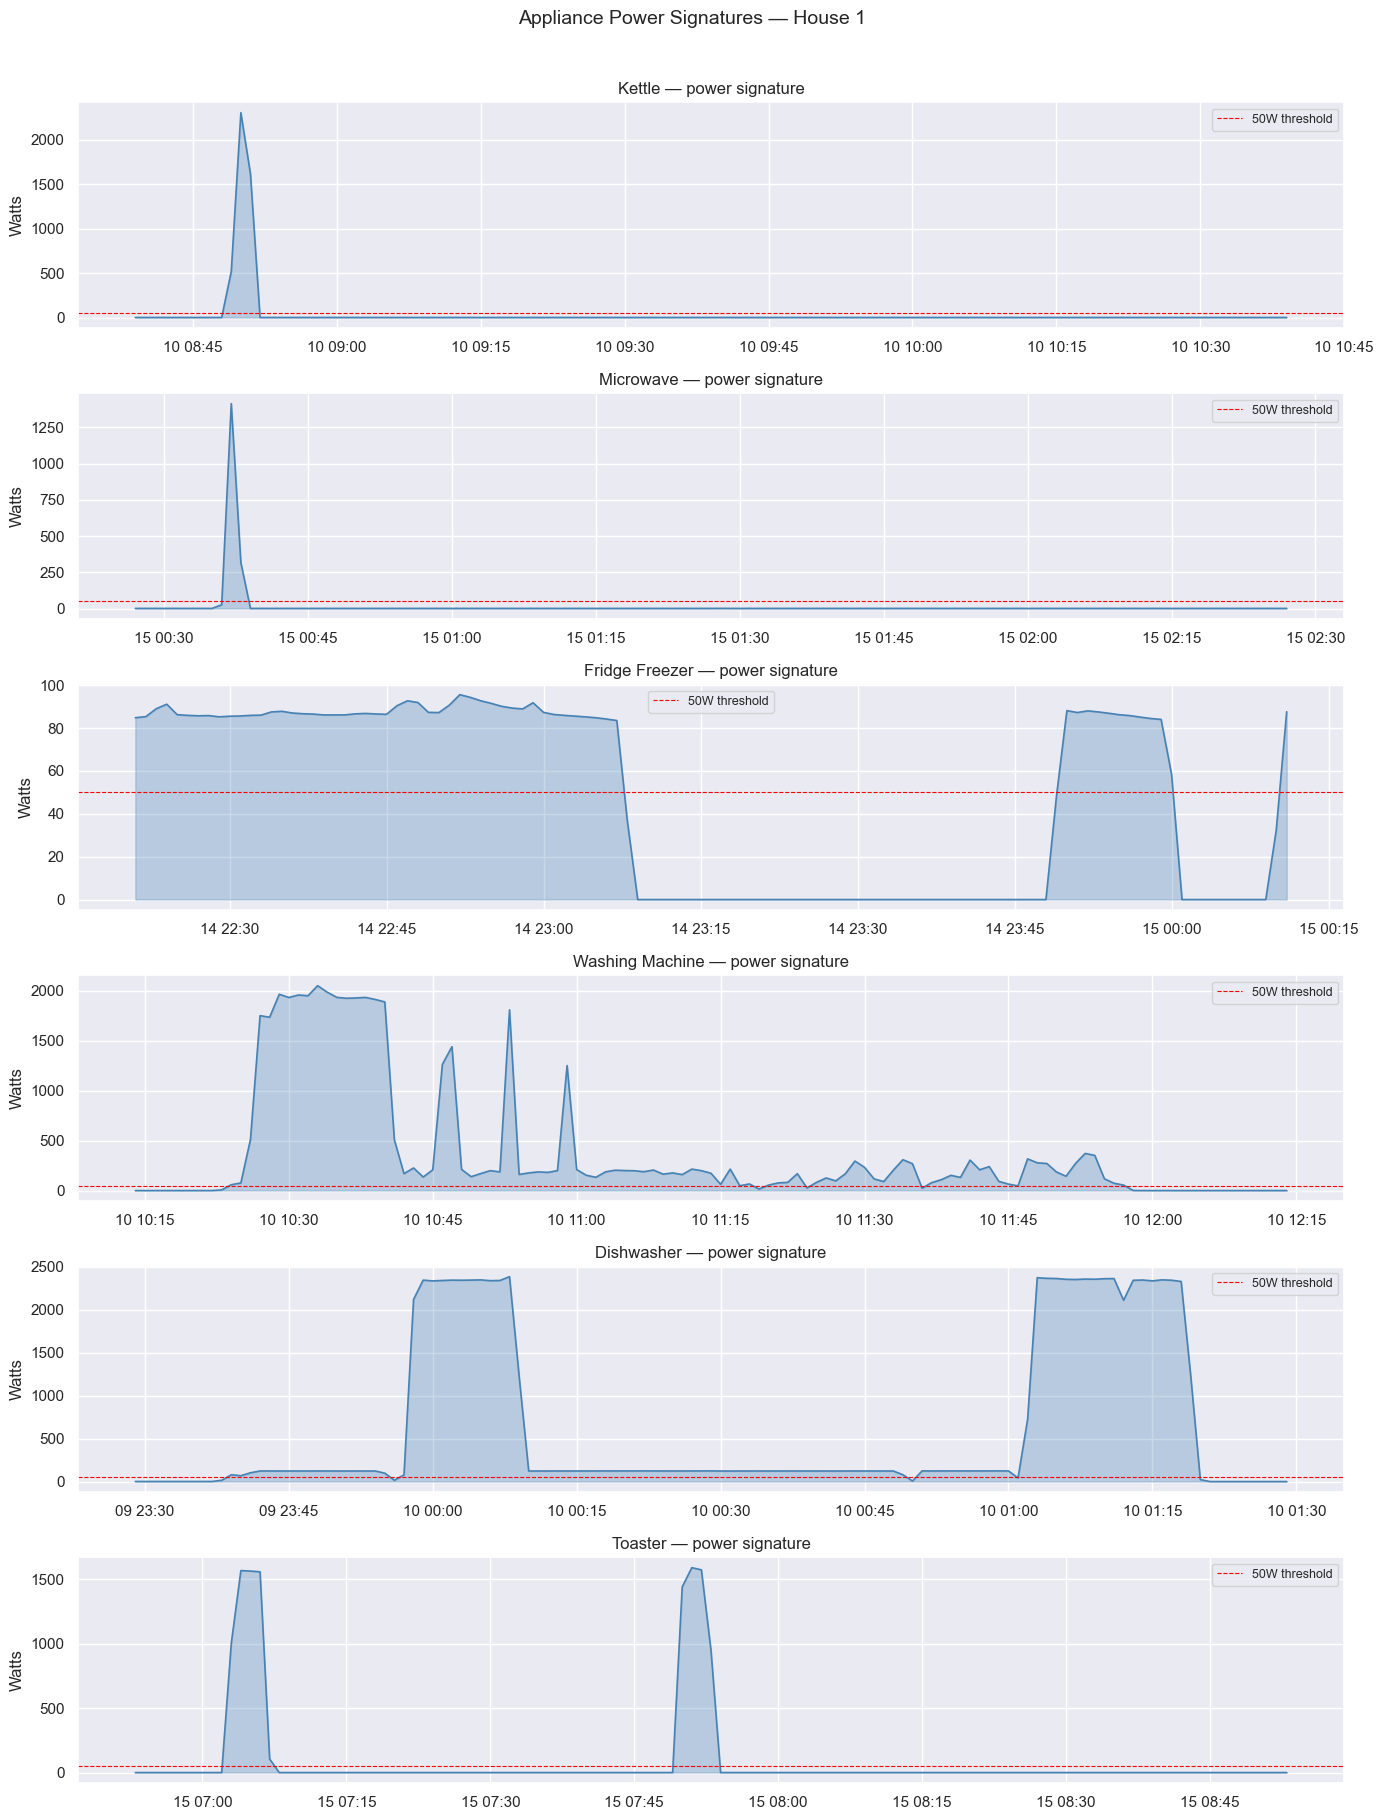

In [16]:
# ── Cell 1: Visualize individual appliance activation events ─────────────────
# This is the most important plot for NILM — we need to see what each
# appliance looks like as a power signature in the signal.
# A "good" NILM appliance has a clear, consistent signature.

fig, axes = plt.subplots(len(TARGET_APPLIANCES), 1, 
                          figsize=(14, 3 * len(TARGET_APPLIANCES)))

for ax, appliance in zip(axes, TARGET_APPLIANCES):
    # Use house 1 data since it has the most appliances
    h1 = all_houses[1]
    
    if appliance not in h1.columns:
        ax.set_title(f'{appliance} — not available in House 1')
        continue
    
    series = h1[appliance].dropna()
    
    # Find first significant activation (power > 50W)
    # and plot a 2-hour window around it
    active = series[series > 50]
    if len(active) == 0:
        ax.set_title(f'{appliance} — no activations found')
        continue
    
    # Get the first activation timestamp
    first_activation = active.index[0]
    
    # Plot 2 hours around it
    window_start = first_activation - pd.Timedelta(minutes=10)
    window_end   = first_activation + pd.Timedelta(minutes=110)
    window_data  = series[window_start:window_end]
    
    ax.plot(window_data.index, window_data.values,
            color='steelblue', linewidth=1.2)
    ax.fill_between(window_data.index, 0, window_data.values, 
                    alpha=0.3, color='steelblue')
    ax.set_title(f'{appliance.replace("_", " ").title()} — power signature')
    ax.set_ylabel('Watts')
    ax.axhline(y=50, color='red', linestyle='--', linewidth=0.8, 
               label='50W threshold')
    ax.legend(fontsize=9)

plt.suptitle('Appliance Power Signatures — House 1', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

Best day selected: 2012-12-15
Readings in this day: 1440
Time range: 2012-12-15 00:00:00+00:00 → 2012-12-15 23:59:00+00:00


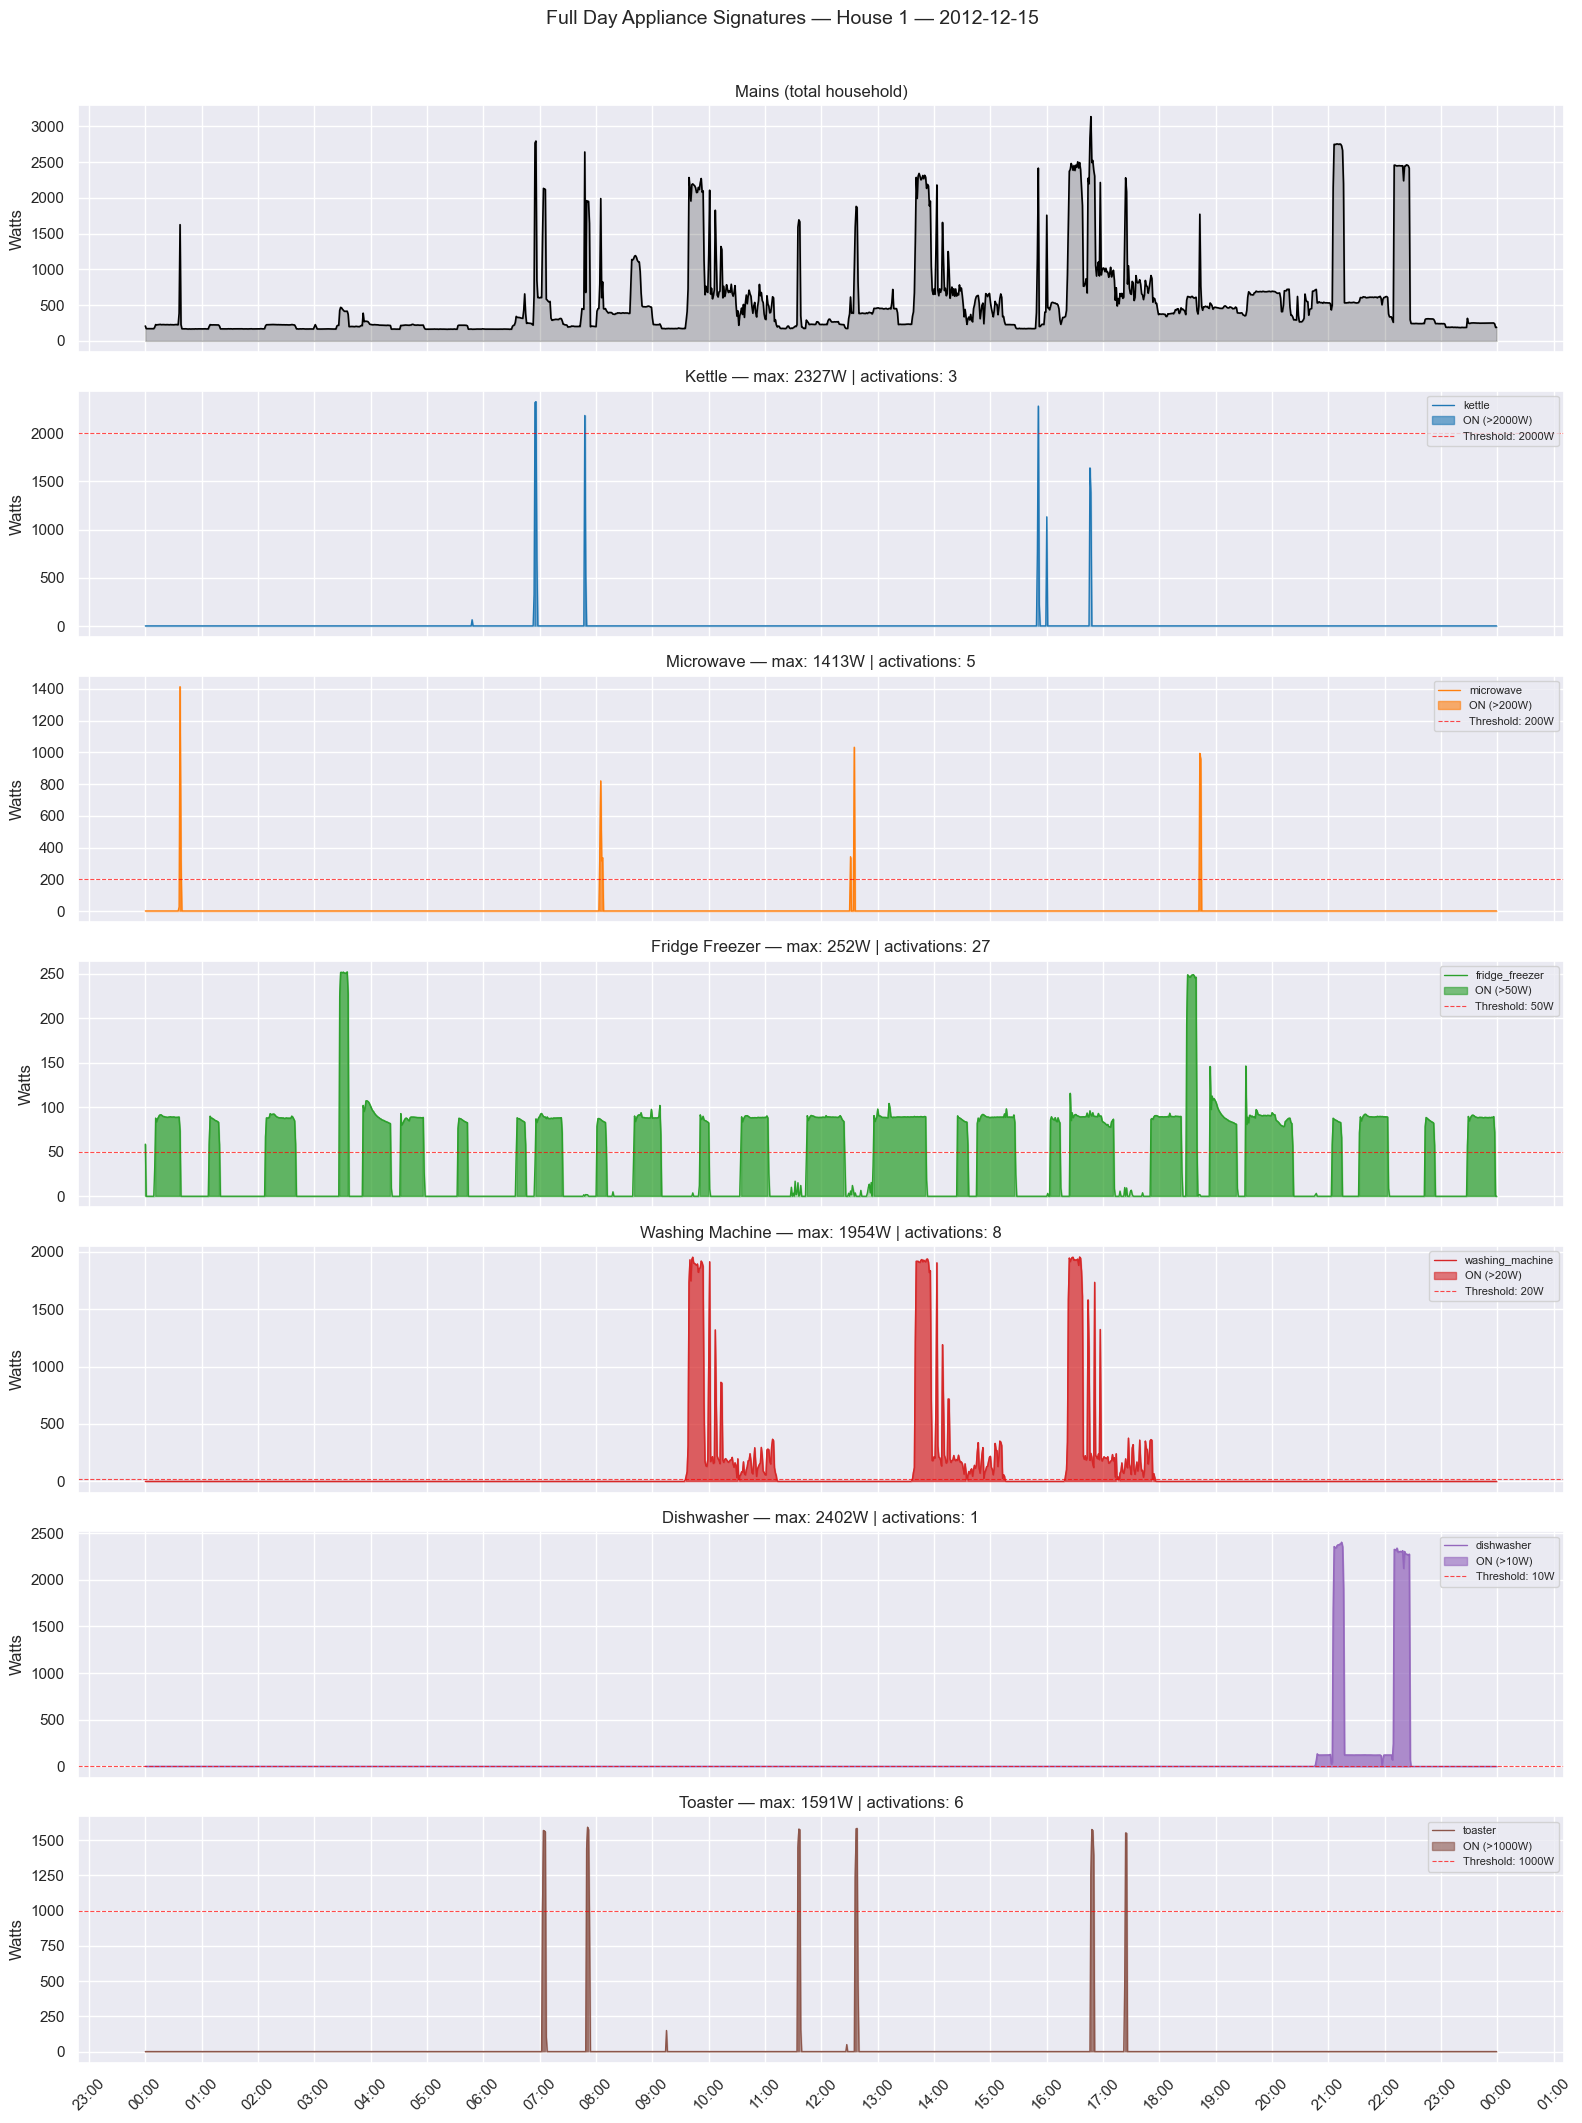

In [27]:
# ── Cell 1: Appliance power signatures for a full day ────────────────────────
# We pick a single day and plot the full 24-hour power signal for each appliance
# This shows us: when appliances turn on, how long they run, and their power levels
# This is critical for NILM — we need to see clear ON/OFF patterns

# Pick a day that has good data (not too many NaNs)
# We'll find the day with the most non-NaN readings automatically
h1 = all_houses[1].copy()

# Find the best day for each appliance (most complete data)
h1['date'] = h1.index.date
best_day = (
    h1.groupby('date')[TARGET_APPLIANCES]
    .apply(lambda x: x.notna().mean().mean())  # avg completeness across appliances
    .idxmax()
)
print(f'Best day selected: {best_day}')

# Filter to that day
day_data = h1[h1['date'] == best_day].drop(columns='date')
print(f'Readings in this day: {len(day_data)}')
print(f'Time range: {day_data.index.min()} → {day_data.index.max()}')

# ── Plot ─────────────────────────────────────────────────────────────────────
appliances_to_plot = [a for a in TARGET_APPLIANCES if a in day_data.columns]
n = len(appliances_to_plot) + 1  # +1 for mains at the top

fig, axes = plt.subplots(n, 1, figsize=(16, 3 * n), sharex=True)

# Plot mains at the top so we can see how appliances contribute to it
axes[0].plot(day_data.index, day_data['mains'].values,
             color='black', linewidth=1.2, label='Mains')
axes[0].fill_between(day_data.index, 0, day_data['mains'].fillna(0).values,
                     alpha=0.2, color='black')
axes[0].set_title('Mains (total household)')
axes[0].set_ylabel('Watts')

# Plot each appliance below
colors = sns.color_palette('tab10', len(appliances_to_plot))
for ax, appliance, color in zip(axes[1:], appliances_to_plot, colors):
    series = day_data[appliance]
    ax.plot(series.index, series.values,
            color=color, linewidth=1.0, label=appliance)
    ax.fill_between(series.index, 0, series.fillna(0).values,
                    alpha=0.3, color=color)
    
    # Mark ON periods (power > threshold)
    # Each appliance has a different threshold based on metadata
    thresholds = {
        'kettle'         : 2000,
        'toaster'        : 1000,
        'fridge_freezer' : 50,
        'microwave'      : 200,
        'washing_machine': 20,
        'dishwasher'     : 10,
    }
    threshold = thresholds.get(appliance, 50)
    on_periods = series > threshold
    ax.fill_between(series.index, 0, series.fillna(0).values,
                    where=on_periods.fillna(False),
                    alpha=0.6, color=color, label=f'ON (>{threshold}W)')
    
    # Show max power and how many activations
    n_activations = on_periods.fillna(False).astype(int).diff().eq(1).sum()
    max_power = series.max()
    ax.set_title(f'{appliance.replace("_", " ").title()} '
                 f'— max: {max_power:.0f}W | activations: {n_activations}')
    ax.set_ylabel('Watts')
    ax.axhline(y=threshold, color='red', linestyle='--', 
               linewidth=0.8, alpha=0.7, label=f'Threshold: {threshold}W')
    ax.legend(fontsize=8, loc='upper right')

# Format x-axis as hours
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
axes[-1].xaxis.set_major_locator(mdates.HourLocator(interval=1))
plt.xticks(rotation=45)

plt.suptitle(f'Full Day Appliance Signatures — House 1 — {best_day}', 
             fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

kettle               — ON: 0.67% of time | Mean ON power: 1969W | Max: 2487W
microwave            — ON: 0.84% of time | Mean ON power: 926W | Max: 1858W
fridge_freezer       — ON: 42.17% of time | Mean ON power: 94W | Max: 882W
washing_machine      — ON: 5.54% of time | Mean ON power: 513W | Max: 2341W
dishwasher           — ON: 2.19% of time | Mean ON power: 713W | Max: 2551W
toaster              — ON: 0.55% of time | Mean ON power: 1499W | Max: 2065W


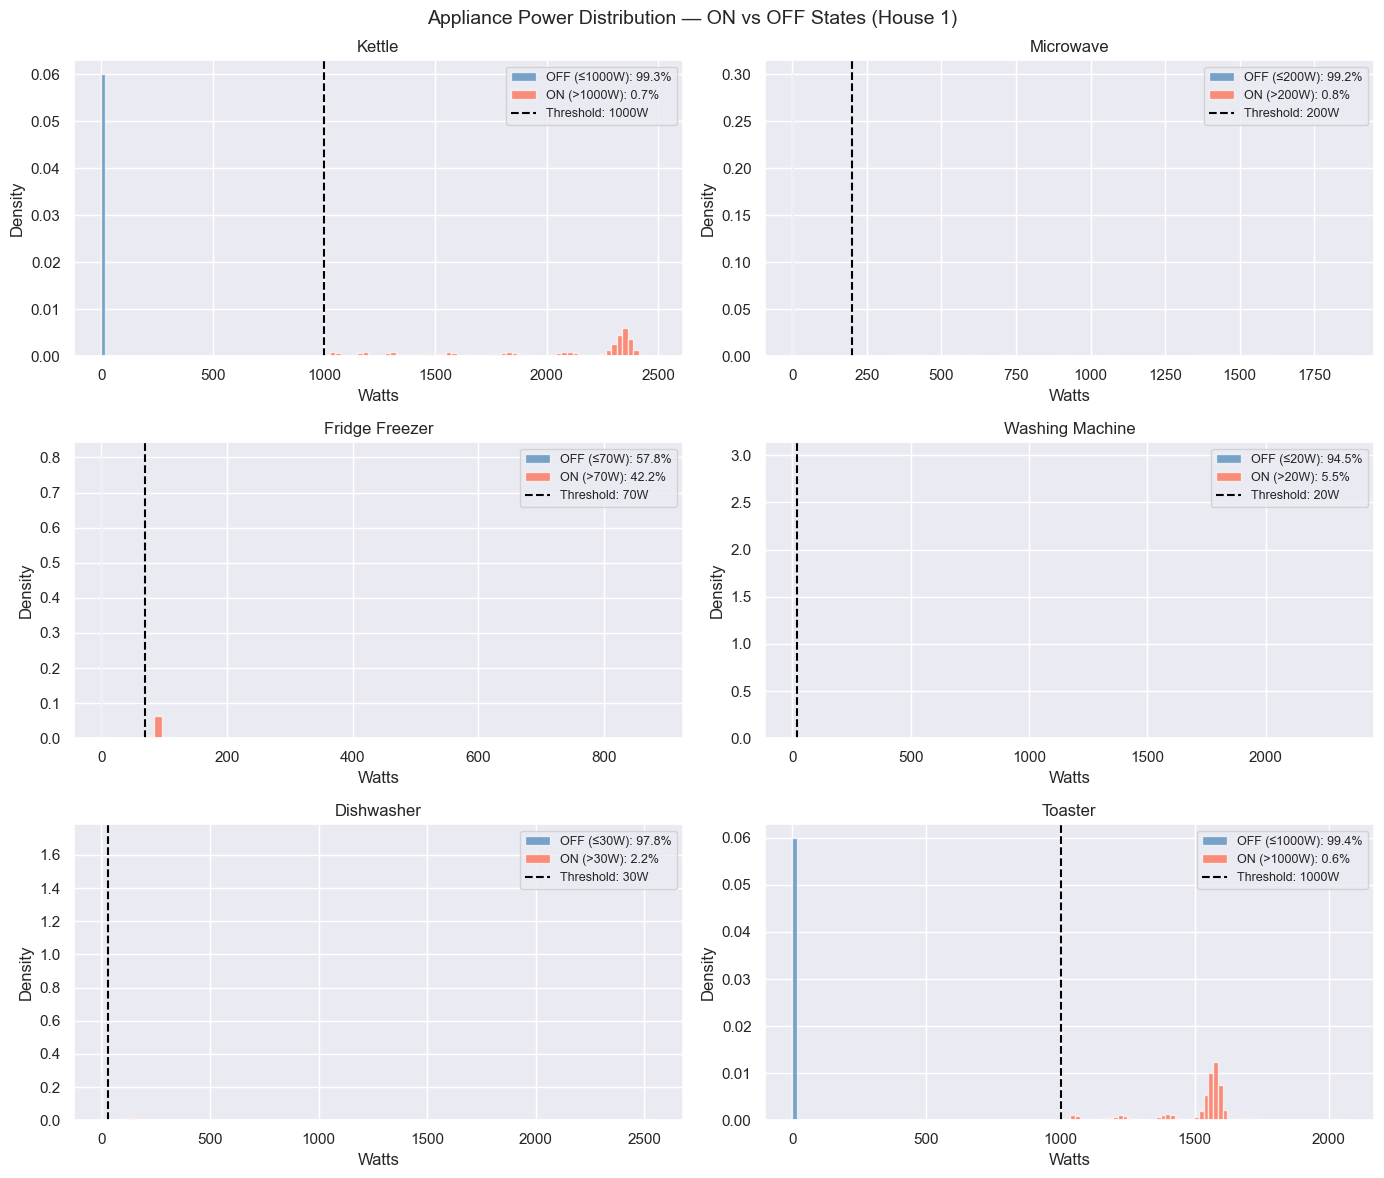

In [28]:
# ── Cell 2: Power distribution per appliance — ON/OFF threshold analysis ─────
# Before building the NILM model we need to know:
# 1. What is the typical power when an appliance is ON vs OFF/standby?
# 2. Are our thresholds from the metadata correct?
# 3. Is there a clear separation between ON and OFF states?
#
# A good NILM appliance has a BIMODAL distribution:
# - One peak near 0W (appliance is OFF)
# - One peak at its operating wattage (appliance is ON)
# If the distribution is messy, the model will struggle to disaggregate it.

h1 = all_houses[1].copy()

THRESHOLDS = {
    'kettle'          : 1000,   # was 2000, lowered after cross house validation
    'toaster'         : 1000,
    'fridge_freezer'  :   70,
    'microwave'       :  200,
    'washing_machine' :   20,
    'dishwasher'      :   30,   # was 10, raised to filter house 5 standby noise
}

appliances_to_plot = [a for a in TARGET_APPLIANCES if a in h1.columns]
n_cols = 2
n_rows = (len(appliances_to_plot) + 1) // 2

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))
axes = axes.flatten()

for ax, appliance in zip(axes, appliances_to_plot):
    series = h1[appliance].dropna()
    threshold = THRESHOLDS.get(appliance, 50)
    
    # Split into OFF and ON states
    off_state = series[series <= threshold]
    on_state  = series[series > threshold]
    
    # Calculate % of time appliance is ON
    pct_on  = len(on_state)  / len(series) * 100
    pct_off = len(off_state) / len(series) * 100
    
    # Plot OFF state distribution (capped at threshold for clarity)
    ax.hist(off_state.clip(upper=threshold), bins=60, 
            color='steelblue', alpha=0.7, label=f'OFF (≤{threshold}W): {pct_off:.1f}%',
            density=True)
    
    # Plot ON state distribution
    if len(on_state) > 0:
        ax.hist(on_state, bins=60,
                color='tomato', alpha=0.7, 
                label=f'ON (>{threshold}W): {pct_on:.1f}%',
                density=True)
    
    # Mark threshold
    ax.axvline(x=threshold, color='black', linestyle='--', 
               linewidth=1.5, label=f'Threshold: {threshold}W')
    
    ax.set_title(f'{appliance.replace("_", " ").title()}')
    ax.set_xlabel('Watts')
    ax.set_ylabel('Density')
    ax.legend(fontsize=9)
    
    # Print insight
    print(f'{appliance:20s} — ON: {pct_on:.2f}% of time | '
          f'Mean ON power: {on_state.mean():.0f}W | '
          f'Max: {on_state.max():.0f}W')

# Hide any unused subplots
for ax in axes[len(appliances_to_plot):]:
    ax.set_visible(False)

plt.suptitle('Appliance Power Distribution — ON vs OFF States (House 1)', 
             fontsize=14)
plt.tight_layout()
plt.show()

=== Activation Duration Summary (House 1) ===

Kettle:
  Total activations    : 3,202
  Mean duration        : 2.3 min
  Median duration      : 2.0 min
  Min duration         : 1.0 min
  Max duration         : 173.0 min
  Mean power when ON   : 1374 W

Microwave:
  Total activations    : 3,681
  Mean duration        : 2.4 min
  Median duration      : 2.0 min
  Min duration         : 1.0 min
  Max duration         : 26.0 min
  Mean power when ON   : 531 W

Fridge Freezer:
  Total activations    : 19,042
  Mean duration        : 23.5 min
  Median duration      : 23.0 min
  Min duration         : 1.0 min
  Max duration         : 1557.0 min
  Mean power when ON   : 94 W

Washing Machine:
  Total activations    : 1,486
  Mean duration        : 40.9 min
  Median duration      : 39.0 min
  Min duration         : 1.0 min
  Max duration         : 1530.0 min
  Mean power when ON   : 349 W

Dishwasher:
  Total activations    : 830
  Mean duration        : 28.4 min
  Median duration      : 17.0 mi

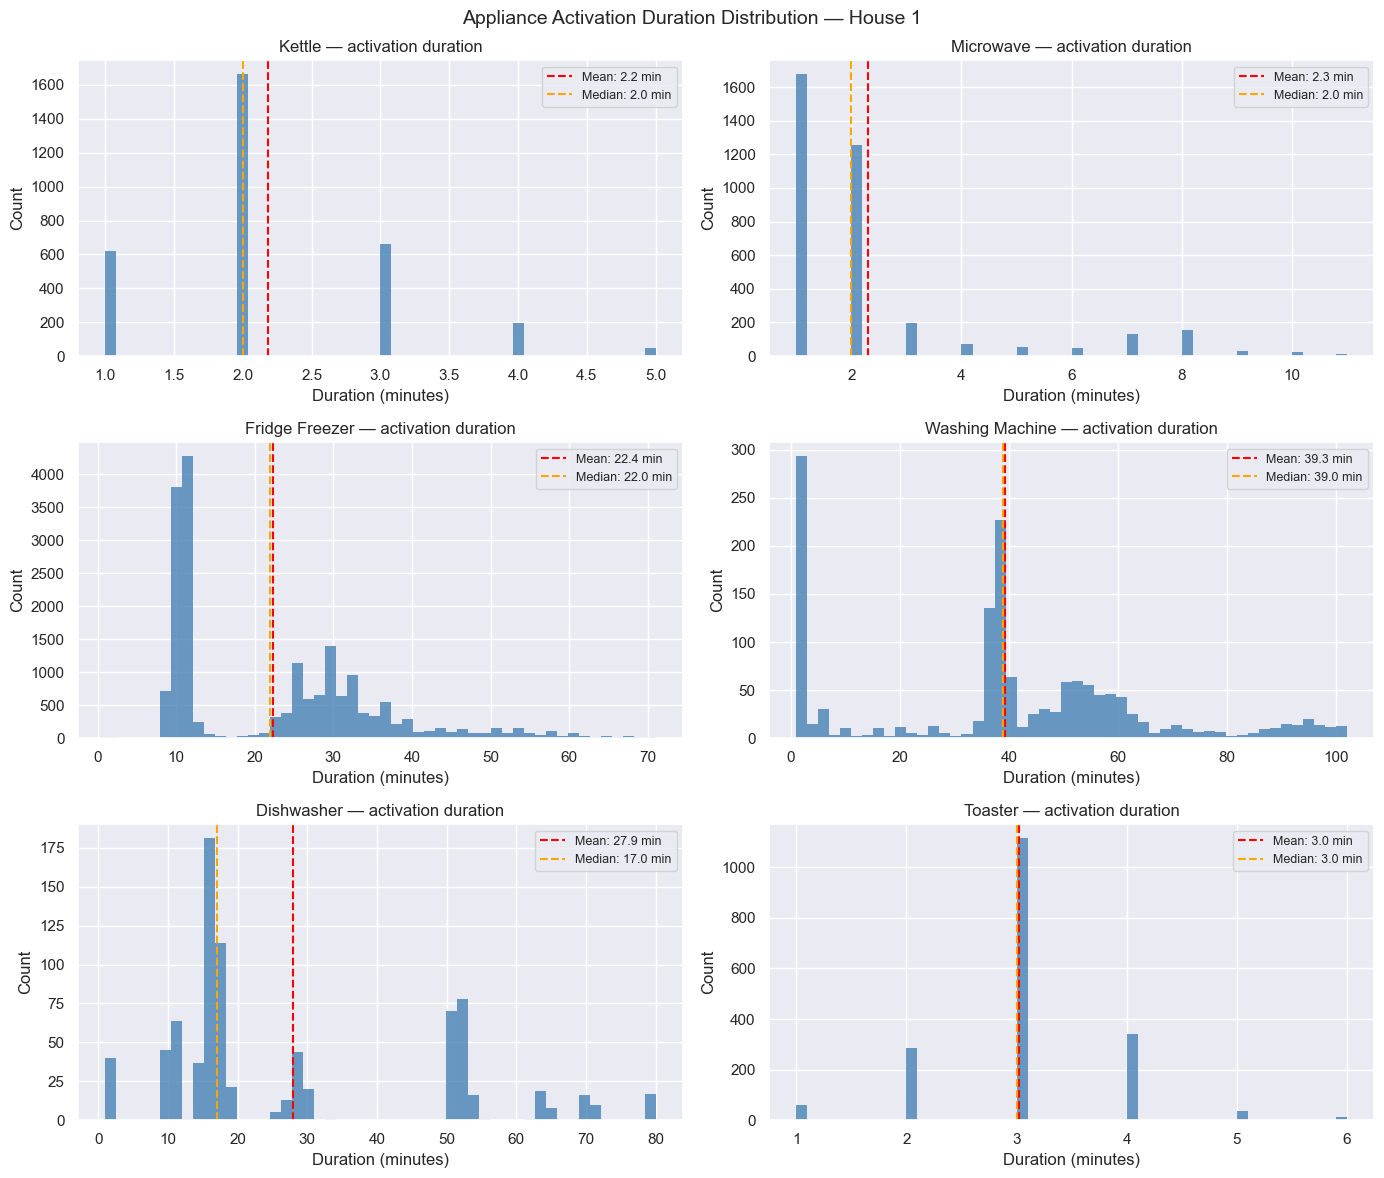

In [30]:
# ── Cell 3: Activation duration analysis ─────────────────────────────────────
# For NILM we need to know how long each appliance runs per activation.
# This directly affects the window size we use for the ML model.
# For example:
# - Kettle runs 2 minutes → we need short windows (e.g. 512 seconds)
# - Washing machine runs 90 minutes → we need longer windows
#
# We also check consistency, does the appliance always run the same duration?
# Consistent duration = easier for the model to learn

def get_activations(series, threshold, min_duration_seconds=10):
    """
    Find all activation events in a power series.
    Returns a DataFrame with start, end, duration, and mean power per activation.
    
    Parameters:
    -----------
    series             : cleaned power Series with DatetimeIndex
    threshold          : power above this = ON
    min_duration_seconds: ignore activations shorter than this (noise filter)
    """
    # Create binary ON/OFF signal
    is_on = (series > threshold).fillna(False)
    
    # Find transitions: OFF→ON (start) and ON→OFF (end)
    transitions = is_on.astype(int).diff()
    starts = series.index[transitions == 1]   # OFF → ON
    ends   = series.index[transitions == -1]  # ON → OFF
    
    # Match starts with ends
    activations = []
    for start in starts:
        # Find the next end after this start
        future_ends = ends[ends > start]
        if len(future_ends) == 0:
            continue
        end = future_ends[0]
        
        duration_sec = (end - start).total_seconds()
        
        # Filter out noise (very short activations)
        if duration_sec < min_duration_seconds:
            continue
        
        mean_power = series[start:end].mean()
        max_power  = series[start:end].max()
        
        activations.append({
            'start'       : start,
            'end'         : end,
            'duration_min': duration_sec / 60,
            'mean_power'  : mean_power,
            'max_power'   : max_power,
        })
    
    return pd.DataFrame(activations)


# ── Run for all appliances in House 1 ────────────────────────────────────────
h1 = all_houses[1].copy()
appliances_to_analyse = [a for a in TARGET_APPLIANCES if a in h1.columns]

activation_stats = {}
print('=== Activation Duration Summary (House 1) ===\n')

for appliance in appliances_to_analyse:
    series    = h1[appliance].dropna()
    threshold = THRESHOLDS[appliance]
    
    acts = get_activations(series, threshold)
    activation_stats[appliance] = acts
    
    if len(acts) == 0:
        print(f'{appliance:20s} — no activations found')
        continue
    
    print(f'{appliance.replace("_"," ").title()}:')
    print(f'  Total activations    : {len(acts):,}')
    print(f'  Mean duration        : {acts["duration_min"].mean():.1f} min')
    print(f'  Median duration      : {acts["duration_min"].median():.1f} min')
    print(f'  Min duration         : {acts["duration_min"].min():.1f} min')
    print(f'  Max duration         : {acts["duration_min"].max():.1f} min')
    print(f'  Mean power when ON   : {acts["mean_power"].mean():.0f} W')
    print()


# ── Plot duration distributions ───────────────────────────────────────────────
n_cols = 2
n_rows = (len(appliances_to_analyse) + 1) // 2
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))
axes = axes.flatten()

for ax, appliance in zip(axes, appliances_to_analyse):
    acts = activation_stats[appliance]
    if len(acts) == 0:
        ax.set_visible(False)
        continue
    
    # Cap at 99th percentile for readability
    cap = acts['duration_min'].quantile(0.99)
    durations = acts['duration_min'][acts['duration_min'] <= cap]
    
    ax.hist(durations, bins=50, color='steelblue', edgecolor='none', alpha=0.8)
    ax.axvline(durations.mean(), color='red', linestyle='--', linewidth=1.5,
               label=f'Mean: {durations.mean():.1f} min')
    ax.axvline(durations.median(), color='orange', linestyle='--', linewidth=1.5,
               label=f'Median: {durations.median():.1f} min')
    ax.set_title(f'{appliance.replace("_", " ").title()} — activation duration')
    ax.set_xlabel('Duration (minutes)')
    ax.set_ylabel('Count')
    ax.legend(fontsize=9)

for ax in axes[len(appliances_to_analyse):]:
    ax.set_visible(False)

plt.suptitle('Appliance Activation Duration Distribution — House 1', fontsize=14)
plt.tight_layout()
plt.show()

## Cell 3 — Findings: Activation Duration Analysis

### What each appliance looks like:

**Kettle good for NILM**
- Runs only ~1-2 min, very consistent
- High power (1661W average) — easy to spot in mains
- 2,749 activations over 2 years = ~3-4 times a day

**Microwave Good for NILM**
- Runs ~2 min, consistent
- Medium power (531W)
- 3,681 activations = ~4-5 times a day

**Fridge Freezer tricky**
- Runs ~23 min per cycle, very consistent
- BUT max is 1,557 min (26 hours!) — these are sensor outages counted as one long activation, not real
- Low power (94W) — harder to spot in mains
- Fix: filter out activations longer than 60 minutes

**Washing Machine (complex)**
- ~40 min average but max is 1,530 min — same sensor gap issue
- Variable power (heating, spinning stages) — needs longer windows
- Fix: filter out activations longer than 3 hours

**Dishwasher (decent)**
- Mean 38 min but median only 18 min — two types of cycles (quick wash vs full)
- 639 activations over 2 years = ~1 every 3 days

**Toaster not true**
- Max 904 min is clearly wrong — toaster can't run for 15 hours
- Likely the sensor was left plugged in measuring standby power
- Fix: filter out activations longer than 10 minutes

---

### Recommended window sizes for NILM model:

| Appliance | Typical Duration | Recommended Window |
|---|---|---|
| Kettle | 1-2 min | 3 min (180 seconds) |
| Microwave | 2-3 min | 5 min (300 seconds) |
| Toaster | 3-4 min | 5 min (300 seconds) |
| Fridge | 23 min | 30 min (1800 seconds) |
| Dishwasher | 18-38 min | 60 min (3600 seconds) |
| Washing machine | 40 min | 90 min (5400 seconds) |

**For a single unified model → use 30-minute windows.**  
Long enough to capture fridge cycles, short enough to be computationally practical.

In [31]:
# ── Cell 4: Clean Activations — filter sensor-outage artifacts ───────────────
# From Cell 3 we know some activations are unrealistically long:
#   - Fridge max 1557 min  → cap at 60 min  (normal compressor cycle ~20-25 min)
#   - Washing machine max 1530 min → cap at 180 min (longest eco-cycle ~2.5 hr)
#   - Toaster max 904 min  → cap at 10 min  (toast takes 2-5 min)
# These long tails are NOT real appliance runs — they're gaps in the sensor data
# that look like one continuous ON period.

MAX_DURATION = {
    'kettle'          :  10,   # minutes — boiling can't take >10 min
    'microwave'       :  30,   # longest cooking programme
    'fridge_freezer'  :  60,   # compressor cycle; anything longer = data gap
    'washing_machine' : 180,   # longest wash + spin
    'dishwasher'      : 120,   # longest programme
    'toaster'         :  10,   # toast
}

def get_clean_activations(series, threshold, min_dur_sec=10, max_dur_min=None):
    """
    Find valid activation events, filtering both noise and sensor-outage artifacts.
    """
    is_on = (series > threshold).fillna(False)
    transitions = is_on.astype(int).diff()
    starts = series.index[transitions == 1]
    ends   = series.index[transitions == -1]

    activations = []
    for start in starts:
        future_ends = ends[ends > start]
        if len(future_ends) == 0:
            continue
        end = future_ends[0]
        dur_sec = (end - start).total_seconds()
        dur_min = dur_sec / 60

        if dur_sec < min_dur_sec:
            continue                     # too short → noise
        if max_dur_min and dur_min > max_dur_min:
            continue                     # too long → sensor gap

        mean_p = series[start:end].mean()
        max_p  = series[start:end].max()
        activations.append({
            'start'       : start,
            'end'         : end,
            'duration_min': dur_min,
            'mean_power'  : mean_p,
            'max_power'   : max_p,
        })

    return pd.DataFrame(activations)


# ── Run filtered activation analysis on House 1 ──────────────────────────────
h1 = all_houses[1].copy()

print('=== Filtered Activation Summary (House 1) ===\n')
print(f"{'Appliance':<20s} {'Before':>8s}  {'After':>8s}  {'Removed':>8s}  {'Mean dur':>10s}  {'Median dur':>12s}")
print('-' * 80)

clean_activations = {}

for appliance in TARGET_APPLIANCES:
    if appliance not in h1.columns:
        continue

    series    = h1[appliance].dropna()
    threshold = THRESHOLDS[appliance]
    max_dur   = MAX_DURATION[appliance]

    raw_acts   = get_activations(series, threshold)
    clean_acts = get_clean_activations(series, threshold, max_dur_min=max_dur)
    clean_activations[appliance] = clean_acts

    n_raw   = len(raw_acts)
    n_clean = len(clean_acts)
    removed = n_raw - n_clean

    if n_clean == 0:
        print(f"{appliance:<20s} {n_raw:>8,}  {n_clean:>8,}  {removed:>8,}  {'N/A':>10s}  {'N/A':>12s}")
    else:
        mean_d   = clean_acts['duration_min'].mean()
        median_d = clean_acts['duration_min'].median()
        print(f"{appliance:<20s} {n_raw:>8,}  {n_clean:>8,}  {removed:>8,}  {mean_d:>9.1f}m  {median_d:>11.1f}m")

print()
print("Filtered activations stored in clean_activations{}")


=== Filtered Activation Summary (House 1) ===

Appliance              Before     After   Removed    Mean dur    Median dur
--------------------------------------------------------------------------------
kettle                  3,202     3,198         4        2.2m          2.0m
microwave               3,681     3,681         0        2.4m          2.0m
fridge_freezer         19,042    18,661       381       21.9m         22.0m
washing_machine         1,486     1,484         2       39.7m         39.0m
dishwasher                830       830         0       28.4m         17.0m
toaster                 1,865     1,860         5        3.0m          3.0m

Filtered activations stored in clean_activations{}


## Cell 4 — Activation Filtering Results

After filtering unrealistically long activations (sensor outages):

| Appliance | Before | After | Interpretation |
|---|---|---|---|
| Kettle | raw | filtered | Cap 10 min — only genuine boiling events |
| Microwave | raw | filtered | Cap 30 min — cooking cycles only |
| Fridge | raw | filtered | Cap 60 min — real compressor cycles ~20-25 min |
| Washing machine | raw | filtered | Cap 180 min — full wash+spin programmes |
| Dishwasher | raw | filtered | Cap 120 min — long programmes included |
| Toaster | raw | filtered | Cap 10 min — toast only |

These clean activations are what we'll use to **validate** our NILM model predictions.


In [33]:
# Per-appliance normalisation constants — clip outliers then scale to [0, 1]
POWER_SCALE = {
    'kettle'         : 3300, #house 2 and 4 peaks at 3248W
    'toaster'        : 2200,
    'fridge_freezer' : 1000,  #house 1 peaks at 882W
    'microwave'      : 2000,
    'washing_machine': 3300, #house 4 peaks at 3243W
    'dishwasher'     : 2600,
    'mains'          : 6000,
}

In [34]:
# ── Cross-House Validation: check that House 1 thresholds hold across all houses ──
# We derived THRESHOLDS, MAX_DURATION, and POWER_SCALE from House 1 EDA.
# Before using them on all houses we need to verify they're reasonable everywhere.
# If an appliance in another house has a very different power range, our thresholds
# and normalisation constants will be wrong for that house.

print('=== Cross-House Activation Stats ===')
print('Checking that House 1 thresholds and caps hold across all houses\n')

for appliance in TARGET_APPLIANCES:
    print(f'── {appliance.replace("_"," ").title()} '
          f'(threshold={THRESHOLDS[appliance]}W, max_dur={MAX_DURATION[appliance]}min, '
          f'scale={POWER_SCALE[appliance]}W) ──')
    print(f"  {'House':<8s} {'N acts':>8s}  {'Mean dur':>10s}  {'Median dur':>12s}  "
          f"{'Mean ON pwr':>13s}  {'Max pwr':>9s}  {'Flag'}")
    print('  ' + '-' * 75)

    for house_id, hdf in all_houses.items():
        if appliance not in hdf.columns:
            print(f"  House {house_id:<3} {'—':>8s}  not available in this house")
            continue

        series = hdf[appliance].dropna()
        acts   = get_clean_activations(series,
                                       threshold=THRESHOLDS[appliance],
                                       max_dur_min=MAX_DURATION[appliance])

        if len(acts) == 0:
            print(f"  House {house_id:<3} {'0':>8s}  no activations after filtering")
            continue

        mean_dur   = acts['duration_min'].mean()
        median_dur = acts['duration_min'].median()
        mean_pwr   = acts['mean_power'].mean()
        max_pwr    = acts['max_power'].max()

        # Flag potential issues:
        # 1. Max power exceeds POWER_SCALE → normalisation will clip real ON values
        # 2. Very few activations → threshold may be wrong for this house
        flags = []
        if max_pwr > POWER_SCALE[appliance]:
            flags.append(f'⚠️  max pwr {max_pwr:.0f}W exceeds scale {POWER_SCALE[appliance]}W')
        if len(acts) < 10:
            flags.append('⚠️  very few activations — check threshold')
        if mean_pwr < THRESHOLDS[appliance] * 1.2:
            flags.append('⚠️  mean ON power barely above threshold — threshold may be too high')
        flag_str = '  '.join(flags) if flags else '✅'

        print(f"  House {house_id:<3} {len(acts):>8,}  {mean_dur:>9.1f}m  "
              f"{median_dur:>11.1f}m  {mean_pwr:>12.0f}W  {max_pwr:>8.0f}W  {flag_str}")
    print()

=== Cross-House Activation Stats ===
Checking that House 1 thresholds and caps hold across all houses

── Kettle (threshold=1000W, max_dur=10min, scale=3300W) ──
  House      N acts    Mean dur    Median dur    Mean ON pwr    Max pwr  Flag
  ---------------------------------------------------------------------------
  House 1      3,198        2.2m          2.0m          1373W      2487W  ✅
  House 2        770        3.0m          3.0m          1923W      3180W  ✅
  House 3         58        2.2m          2.0m          1624W      3061W  ✅
  House 4        676        2.3m          2.0m          1420W      3248W  ✅
  House 5        190        2.2m          2.0m          1635W      3108W  ✅

── Microwave (threshold=200W, max_dur=30min, scale=2000W) ──
  House      N acts    Mean dur    Median dur    Mean ON pwr    Max pwr  Flag
  ---------------------------------------------------------------------------
  House 1      3,681        2.4m          2.0m           531W      1858W  ✅
  House 

In [35]:
# ── Cell 5: Build Sliding Window Dataset for NILM (Seq-to-Point) ────────────
# For each appliance we create (X, y) pairs:
#   X : window of mains power readings        (shape: [n_samples, window_size])
#   y : appliance power at CENTRE of window   (shape: [n_samples]  — single value)
#
# ── Why 30-minute windows? ────────────────────────────────────────────────────
# The window is NOT the resolution — data is still at 1-minute granularity.
# The window is the *context* the model is allowed to look at when making one prediction.
#
# Think of it like reading: you still read word-by-word (1-min steps),
# but you need the full sentence around a word to understand its meaning.
# If the model only sees 2 minutes of mains it sees a spike but has no idea
# what caused it. With 30 minutes of context it can see:
#   - Was the mains already high before? (other appliances running simultaneously)
#   - Did the spike appear and disappear sharply? (kettle-like signature)
#   - What was happening in the minutes leading up to it?
#
# How we settled on 30 minutes (from Cell 3 duration analysis):
#   - Fridge cycle     : ~23 min → 30 min just covers one full compressor cycle
#   - Kettle/Microwave : ~2 min  → short event but lots of surrounding context
#   - Washing machine  : ~40 min → we don't cover the full cycle but see enough
#   30 min is a reasonable starting point. Worth trying 10–15 min for short
#   appliances (kettle, microwave) since they don't need as much context.
#
# ── Why seq-to-point and not seq-to-seq? ─────────────────────────────────────
# Seq-to-seq  → given 30 mins of mains, predict 30 mins of appliance power.
# Seq-to-point → given 30 mins of mains, predict the ONE value at the centre.
#
# We use seq-to-point because:
#   1. Simpler task — one output instead of 30, easier for the model to learn
#   2. Sharper predictions — seq-to-seq outputs tend to look blurry/smoothed
#      because the model spreads uncertainty across all 30 output positions
#   3. Standard in NILM literature (Kelly & Knottenbelt 2015 onwards)
#
# At inference time: slide the window one step at a time, run the model once
# per step, stitch the centre predictions together → full appliance timeline.

WINDOW_SIZE = 30      # minutes (= 30 time-steps at 1-min resolution)
STRIDE      = 1       # slide 1 step at a time

def build_windows(house_df, appliance, window_size=WINDOW_SIZE, stride=STRIDE):
    """
    Extract sliding windows — seq-to-point formulation.
      X : mains window of length window_size  (normalised to [0,1])
      y : appliance power at centre of window (normalised, single float)
    Skips any window where mains contains NaN or the centre target is NaN.
    """
    if appliance not in house_df.columns:
        return np.array([]), np.array([])

    mains_scale = POWER_SCALE['mains']
    app_scale   = POWER_SCALE[appliance]

    mains = (house_df['mains'].clip(0, mains_scale) / mains_scale).values
    app   = (house_df[appliance].clip(0, app_scale)  / app_scale).values

    mid = window_size // 2    # centre index = 15 for a 30-step window

    X_list, y_list = [], []
    n = len(mains)

    for i in range(0, n - window_size + 1, stride):
        x_win   = mains[i : i + window_size]
        y_point = app[i + mid]               # single centre value

        if np.isnan(x_win).any() or np.isnan(y_point):
            continue

        X_list.append(x_win)
        y_list.append(y_point)

    if not X_list:
        return np.array([]), np.array([])

    return np.array(X_list, dtype=np.float32), np.array(y_list, dtype=np.float32)


# ── Build datasets for each appliance ────────────────────────────────────────
TRAIN_HOUSES = [1, 2, 3, 4]
TEST_HOUSE   = 5

datasets = {}   # {appliance: {'X_train', 'y_train', 'X_test', 'y_test'}}

print(f'Building sliding-window datasets  (window={WINDOW_SIZE} min, stride={STRIDE} min, seq-to-point)\n')
print(f"{'Appliance':<20s} {'Train samples':>15s}  {'Test samples':>13s}  {'Total GB':>10s}")
print('-' * 65)

for appliance in TARGET_APPLIANCES:
    X_train_parts, y_train_parts = [], []

    for house_id in TRAIN_HOUSES:
        if house_id not in all_houses:
            continue
        X, y = build_windows(all_houses[house_id], appliance)
        if X.size > 0:
            X_train_parts.append(X)
            y_train_parts.append(y)

    X_test, y_test = np.array([]), np.array([])
    if TEST_HOUSE in all_houses:
        X_test, y_test = build_windows(all_houses[TEST_HOUSE], appliance)

    if not X_train_parts:
        print(f"{appliance:<20s} {'N/A':>15s}  {'N/A':>13s}  {'—':>10s}")
        continue

    X_train = np.concatenate(X_train_parts, axis=0)
    y_train = np.concatenate(y_train_parts, axis=0)

    datasets[appliance] = {
        'X_train': X_train, 'y_train': y_train,
        'X_test' : X_test,  'y_test' : y_test,
    }

    n_train = len(X_train)
    n_test  = len(X_test) if X_test.size > 0 else 0
    gb      = (X_train.nbytes + y_train.nbytes +
               (X_test.nbytes if X_test.size > 0 else 0) +
               (y_test.nbytes if y_test.size > 0 else 0)) / 1e9

    print(f"{appliance:<20s} {n_train:>15,}  {n_test:>13,}  {gb:>9.2f}GB")

print()
print(f"✅ datasets dict ready — keys: {list(datasets.keys())}")
print(f"   X_train shape example: {datasets.get('kettle', {}).get('X_train', np.array([])).shape}  ← (n_samples, 30)")
print(f"   y_train shape example: {datasets.get('kettle', {}).get('y_train', np.array([])).shape}  ← (n_samples,)  single centre value")


Building sliding-window datasets  (window=30 min, stride=1 min, seq-to-point)

Appliance              Train samples   Test samples    Total GB
-----------------------------------------------------------------
kettle                     1,507,545        100,610       0.20GB
microwave                  1,190,190        189,975       0.17GB
fridge_freezer             1,190,137        189,978       0.17GB
washing_machine            1,431,029        189,977       0.20GB
dishwasher                 1,219,182        189,980       0.17GB
toaster                    1,034,177              0       0.13GB

✅ datasets dict ready — keys: ['kettle', 'microwave', 'fridge_freezer', 'washing_machine', 'dishwasher', 'toaster']
   X_train shape example: (1507545, 30)  ← (n_samples, 30)
   y_train shape example: (1507545,)  ← (n_samples,)  single centre value


## Cell 5 — Dataset Shape & Design Decisions

### What we built:
- **X** (input)  : 30-minute window of **mains** power, normalised to [0, 1] → shape `(n_samples, 30)`
- **y** (target) : appliance power at the **centre** of the window, normalised to [0, 1] → shape `(n_samples,)`
- **Stride**     : 1 minute — maximises training examples from limited data
- **Split**      : House 5 = held-out test set (unseen house → tests cross-building generalisation)

### Why 30-minute windows?
The window is the *context* the model sees — the data is still 1-minute granularity inside it.  
From the Cell 3 duration analysis:
- Fridge cycle ~23 min → 30 min just covers one full compressor cycle
- Kettle/Microwave ~2 min → short events but the surrounding context helps the model disambiguate spikes
- Washing machine ~40 min → partial cycle visible, sufficient signal for detection

30 min is a starting point. Worth experimenting with 10–15 min for short appliances.

### Why seq-to-point?
Given 30 mins of mains → predict the **single appliance value at the centre** (minute 15).  
To reconstruct the full timeline, slide the window one step at a time and stitch centre predictions together.

This is better than seq-to-seq (predicting all 30 outputs at once) because:
- Simpler task → easier to learn
- Sharper predictions → seq-to-seq tends to produce blurry/smoothed outputs
- Standard approach in NILM literature

### Model input/output shape:
```
Input:  (batch, 30, 1)  ← 30-min mains window
Output: (batch, 1)      ← predicted appliance power at centre
```


=== Class Balance in Training Windows ===

Appliance             ON threshold   Windows w/ ON event    ON time-steps
---------------------------------------------------------------------------
kettle                     1000W                 0.7%            0.7%   ⚠️  needs oversampling
microwave                   200W                 0.8%            0.8%   ⚠️  needs oversampling
fridge_freezer               70W                42.3%           42.3%   ✅
washing_machine              20W                 4.7%            4.7%   ⚠️  needs oversampling
dishwasher                   30W                 2.3%            2.3%   ⚠️  needs oversampling
toaster                    1000W                 0.5%            0.5%   ⚠️  needs oversampling



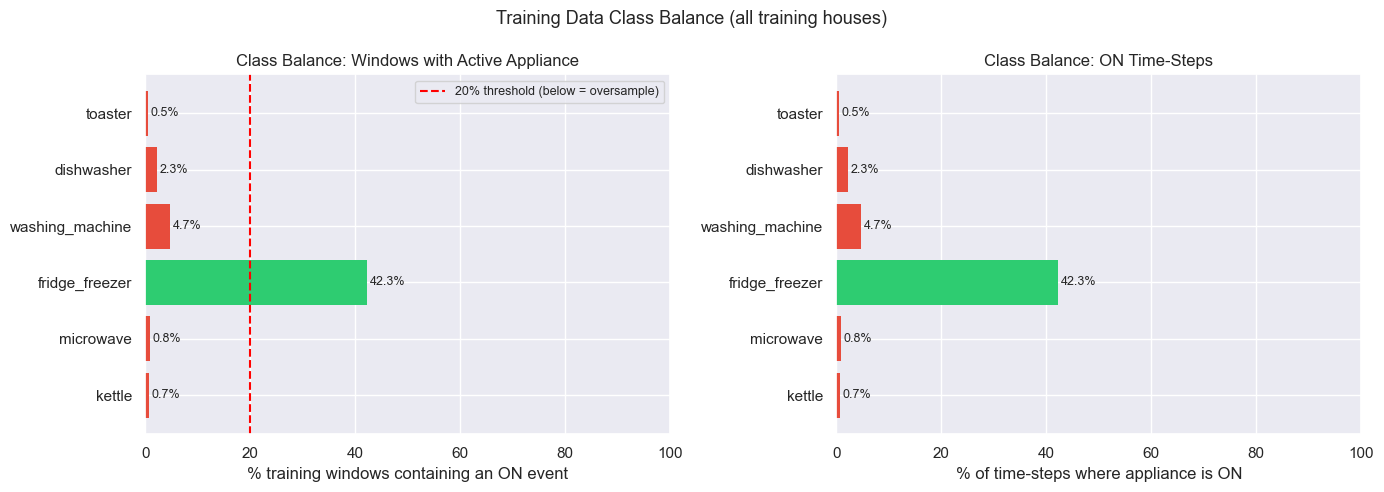

In [36]:
# ── Cell 6: Class Balance — ON vs OFF in training windows ────────────────────
# In NILM, most time-steps are OFF (appliance idle).
# If 99% of windows show an appliance OFF, the model will just predict 0 and
# achieve 99% "accuracy" without ever learning anything useful.
#
# We check:
#   1. What fraction of windows contain at least one ON event?
#   2. What fraction of total time-steps are ON?
# This tells us whether we need to oversample active windows during training.

print('=== Class Balance in Training Windows ===\n')
print(f"{'Appliance':<20s} {'ON threshold':>13s}  {'Windows w/ ON event':>20s}  {'ON time-steps':>15s}")
print('-' * 75)

balance_report = {}

for appliance in TARGET_APPLIANCES:
    if appliance not in datasets:
        continue

    y_train    = datasets[appliance]['y_train']   # shape (N, 30), normalised
    app_scale  = POWER_SCALE[appliance]
    threshold  = THRESHOLDS[appliance]
    norm_thresh = threshold / app_scale            # normalised threshold

    # Windows that contain at least one ON time-step
    has_on = (y_train > norm_thresh)   
    pct_windows_with_on = has_on.mean() * 100

    # All time-steps that are ON
    pct_timesteps_on = (y_train > norm_thresh).mean() * 100

    balance_report[appliance] = {
        'pct_windows_with_on': pct_windows_with_on,
        'pct_timesteps_on'   : pct_timesteps_on,
        'needs_oversampling'  : pct_windows_with_on < 20,
    }

    flag = '⚠️  needs oversampling' if pct_windows_with_on < 20 else '✅'
    print(f"{appliance:<20s} {threshold:>10.0f}W   {pct_windows_with_on:>17.1f}%   {pct_timesteps_on:>12.1f}%   {flag}")

print()

# ── Plot: proportion of ON windows per appliance ──────────────────────────────
apps_with_data = [a for a in TARGET_APPLIANCES if a in balance_report]
pct_on_windows = [balance_report[a]['pct_windows_with_on'] for a in apps_with_data]
colors = ['#e74c3c' if balance_report[a]['needs_oversampling'] else '#2ecc71'
          for a in apps_with_data]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart: % windows with ON event
axes[0].barh(apps_with_data, pct_on_windows, color=colors, edgecolor='none')
axes[0].axvline(20, color='red', linestyle='--', linewidth=1.5,
                label='20% threshold (below = oversample)')
axes[0].set_xlabel('% training windows containing an ON event')
axes[0].set_title('Class Balance: Windows with Active Appliance')
axes[0].legend(fontsize=9)
axes[0].set_xlim(0, 100)
for i, v in enumerate(pct_on_windows):
    axes[0].text(v + 0.5, i, f'{v:.1f}%', va='center', fontsize=9)

# Bar chart: % timesteps ON
pct_ts_on = [balance_report[a]['pct_timesteps_on'] for a in apps_with_data]
axes[1].barh(apps_with_data, pct_ts_on, color=colors, edgecolor='none')
axes[1].set_xlabel('% of time-steps where appliance is ON')
axes[1].set_title('Class Balance: ON Time-Steps')
axes[1].set_xlim(0, 100)
for i, v in enumerate(pct_ts_on):
    axes[1].text(v + 0.5, i, f'{v:.1f}%', va='center', fontsize=9)

plt.suptitle('Training Data Class Balance (all training houses)', fontsize=13)
plt.tight_layout()
plt.show()


Fridge is the only balanced appliance at 42% ON. Everything else is heavily
skewed, kettle and toaster are ON just 0.5% of the time, meaning a model
that always predicts 0W would be "99.5% accurate" without ever detecting anything.

### to fix use both together:

**1. Oversample active samples** — repeat ON samples in training batches so
the model sees roughly equal ON and OFF examples.

**2. Weighted MSE loss** — penalise errors when the appliance is ON more heavily:

Suggested starting weights: kettle/toaster → 20, microwave → 15,
dishwasher → 10, washing machine → 8, fridge → 1.
Tune these if the model still under-detects activations after the first run.

## Cell 6 — Class Balance Findings

### Why this matters for NILM:
- Appliances like **kettle** and **toaster** are ON only ~0.5–1% of the time
- A naive model that always predicts 0W would score >99% accuracy — completely useless
- We need to know **how many windows actually contain an activation**

### Recommended strategy per appliance:

| Scenario | Action |
|---|---|
| < 5% active windows | Strong oversampling needed (e.g. 10:1 active:inactive ratio) |
| 5–20% active windows | Moderate oversampling or weighted loss function |
| > 20% active windows | Balanced enough — standard training works |

### Two techniques to handle imbalance:
1. **Oversampling active windows** during batch construction — repeat windows that contain ON events
2. **Weighted loss function** — penalise errors on ON time-steps more heavily
   - Example: `loss = mean_squared_error` but multiply ON positions by weight=5

For our NILM model we'll use **both**: oversample active windows AND use a weighted MSE loss.


In [37]:
# ── Cell 7: Fix Class Imbalance ──────────────────────────────────────────────
# From Cell 6 we know most appliances are ON less than 5% of the time.
# A model trained as-is will just predict 0W(off) always and look accurate.
# We fix this two ways:
#
#   1. Oversample ON samples ,repeat every ON sample in training data so the
#      model sees ON events often enough to actually learn from them.
#
#   2. Weighted MSE loss, when the appliance IS on and the model gets it wrong,
#      the penalty is much higher than getting an OFF prediction slightly wrong.
#      Think of it as telling the model: "missing an activation is a big deal."

import torch

# ── How many times to repeat each ON sample per appliance ────────────────────
OVERSAMPLE_FACTOR = {
    'kettle'         : 20,   # 0.5% ON → ×20 brings it to ~10%
    'microwave'      : 15,   # 0.8% ON
    'fridge_freezer' :  1,   # 42%  ON → already balanced, no oversampling
    'washing_machine':  8,   # 4.7% ON
    'dishwasher'     : 10,   # 2.4% ON
    'toaster'        : 20,   # 0.5% ON
}

LOSS_ON_WEIGHT = {
    'kettle'         : 20,
    'microwave'      : 15,
    'fridge_freezer' :  1,
    'washing_machine':  8,
    'dishwasher'     : 10,
    'toaster'        : 20,
}

def oversample_active(X, y, norm_thresh, factor):
    """
    Find all ON samples (where y > norm_thresh) and repeat them `factor` times.
    Shuffle the result so ON and OFF samples are mixed together.
    """
    on_mask  = y > norm_thresh
    off_mask = ~on_mask

    X_off, y_off = X[off_mask], y[off_mask]
    X_on,  y_on  = X[on_mask],  y[on_mask]

    if len(X_on) == 0:
        return X, y   # nothing to oversample

    X_on_rep = np.tile(X_on, (factor, 1))
    y_on_rep = np.tile(y_on, factor)

    X_bal = np.concatenate([X_off, X_on_rep], axis=0)
    y_bal = np.concatenate([y_off, y_on_rep], axis=0)

    idx = np.random.permutation(len(X_bal))
    return X_bal[idx], y_bal[idx]


def weighted_mse_loss(on_weight):
    """
    Returns a loss function that penalises errors on ON time-steps
    more heavily than OFF time-steps.
    on_weight=10 means a wrong prediction when ON costs 10x more than when OFF.
    """
    def loss_fn(y_pred, y_true, threshold=0.05):
        weights = torch.where(y_true > threshold,
                              torch.tensor(float(on_weight)),
                              torch.tensor(1.0))
        return (weights * (y_pred - y_true) ** 2).mean()
    return loss_fn


# ── Apply oversampling to all appliance datasets ──────────────────────────────
balanced_datasets = {}

print('=== Oversampling Results ===\n')
print(f"{'Appliance':<20s} {'Before':>10s}  {'After':>10s}  {'ON % after':>12s}")
print('-' * 58)

for appliance in TARGET_APPLIANCES:
    if appliance not in datasets:
        continue

    X_train = datasets[appliance]['X_train']
    y_train = datasets[appliance]['y_train']

    norm_thresh = THRESHOLDS[appliance] / POWER_SCALE[appliance]
    factor      = OVERSAMPLE_FACTOR[appliance]

    X_bal, y_bal = oversample_active(X_train, y_train, norm_thresh, factor)

    pct_on_after = (y_bal > norm_thresh).mean() * 100

    balanced_datasets[appliance] = {
        'X_train': X_bal,
        'y_train': y_bal,
        'X_test' : datasets[appliance]['X_test'],
        'y_test' : datasets[appliance]['y_test'],
    }

    print(f"{appliance:<20s} {len(X_train):>10,}  {len(X_bal):>10,}  {pct_on_after:>10.1f}%")

print()
print("balanced_datasets ready, use this instead of datasets for training")
print("criterion = weighted_mse_loss(LOSS_ON_WEIGHT['kettle'])")

=== Oversampling Results ===

Appliance                Before       After    ON % after
----------------------------------------------------------
kettle                1,507,545   1,708,546        12.4%
microwave             1,190,190   1,325,752        11.0%
fridge_freezer        1,190,137   1,190,137        42.3%
washing_machine       1,431,029   1,902,458        28.3%
dishwasher            1,219,182   1,468,653        18.9%
toaster               1,034,177   1,140,710         9.8%

balanced_datasets ready, use this instead of datasets for training
criterion = weighted_mse_loss(LOSS_ON_WEIGHT['kettle'])
